In [4]:
import json
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import random
import torch

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42

set_seed(SEED)

sns.set_style("whitegrid")
print("Libraries imported successfully.")

DATASET = "IMDB"
TEXT_COLUMN = "text_original"
LABEL_COLUMN = "label"
ROOT_DIR = os.getcwd()

EDA_DIR = os.path.join(ROOT_DIR, "EDA", DATASET)
os.makedirs(EDA_DIR, exist_ok=True)

print(f"Dataset:      {DATASET}")
print(f"Text column:  {TEXT_COLUMN}")
print(f"Label column: {LABEL_COLUMN}")
print(f"Root dir:     {ROOT_DIR}")
print(f"EDA dir:      {EDA_DIR}")

Libraries imported successfully.
Dataset:      IMDB
Text column:  text_original
Label column: label
Root dir:     c:\Users\cemil\OneDrive\Desktop\NLP
EDA dir:      c:\Users\cemil\OneDrive\Desktop\NLP\EDA\IMDB


In [5]:
dataset_path = os.path.join(ROOT_DIR, DATASET)

def load_split(split_name):
    file_path = os.path.join(dataset_path, f"{split_name}.json")
    if not os.path.exists(file_path):
        print(f"  {split_name}.json not found in {dataset_path}")
        return None
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    print(f"  {split_name}.json: {len(df)} samples")
    return df

print(f"Loading data from: {dataset_path}\n")
df_train = load_split("train")
df_validation = load_split("validation")
df_test = load_split("test")

if df_train is not None:
    print(f"\nFirst 3 train examples:")
    display(df_train.head(3))

Loading data from: c:\Users\cemil\OneDrive\Desktop\NLP\IMDB

  train.json: 20000 samples
  validation.json: 5000 samples
  test.json: 25000 samples

First 3 train examples:


,text_original,text_preprocessed,label
0,I have always been a huge James Bond fanatic! ...,i have always been a huge james bond fanatic! ...,1
1,I am a Christian and I say this movie had terr...,i am a christian and i say this movie had terr...,0
2,"Neatly sandwiched between THE STRANGER, a smal...","neatly sandwiched between the stranger, a smal...",1


In [6]:
splits = {"train": df_train, "validation": df_validation, "test": df_test}
splits = {k: v for k, v in splits.items() if v is not None}

print(f"{'='*40}")
print(f"  {DATASET} -- Split sizes")
print(f"{'='*40}")
for split_name, df in splits.items():
    print(f"  {split_name:>12}: {len(df):>6} samples")
total = sum(len(df) for df in splits.values())
print(f"  {'TOTAL':>12}: {total:>6} samples")
print(f"{'='*40}")

for split_name, df in splits.items():
    print(f"\n--- {split_name} ({len(df)} rows) ---")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Missing values:\n{df.isnull().sum().to_string()}")
    print(f"  Duplicates: {df.duplicated(subset=[TEXT_COLUMN]).sum()}")

    has_labels = LABEL_COLUMN in df.columns and df[LABEL_COLUMN].notna().any()
    if has_labels:
        print(f"  Label distribution:\n{df[LABEL_COLUMN].value_counts().sort_index().to_string()}")

  IMDB -- Split sizes
         train:  20000 samples
    validation:   5000 samples
          test:  25000 samples
         TOTAL:  50000 samples

--- train (20000 rows) ---
  Columns: ['text_original', 'text_preprocessed', 'label']
  Missing values:
text_original        0
text_preprocessed    0
label                0
  Duplicates: 59
  Label distribution:
label
0    10000
1    10000

--- validation (5000 rows) ---
  Columns: ['text_original', 'text_preprocessed', 'label']
  Missing values:
text_original        0
text_preprocessed    0
label                0
  Duplicates: 3
  Label distribution:
label
0    2500
1    2500

--- test (25000 rows) ---
  Columns: ['text_original', 'text_preprocessed', 'label']
  Missing values:
text_original        0
text_preprocessed    0
label                0
  Duplicates: 199
  Label distribution:
label
0    12500
1    12500


In [7]:
for split_name, df in splits.items():
    df["word_count"] = df[TEXT_COLUMN].apply(lambda t: len(str(t).split()))
    df["char_count"] = df[TEXT_COLUMN].apply(lambda t: len(str(t)))
    df["avg_word_len"] = df[TEXT_COLUMN].apply(
        lambda t: np.mean([len(w) for w in str(t).split()]) if str(t).split() else 0
    )
    splits[split_name] = df

    print(f"\n--- {split_name} ---")
    p50 = df['word_count'].quantile(0.50)
    p95 = df['word_count'].quantile(0.95)

    print(f"  Word count  -- mean: {df['word_count'].mean():.1f}, "
          f"median: {df['word_count'].median():.0f}, "
          f"min: {df['word_count'].min()}, max: {df['word_count'].max()}")
    print(f"  Word count  -- p50: {p50:.0f}, p95: {p95:.0f}")
    print(f"  Char count  -- mean: {df['char_count'].mean():.1f}, "
          f"median: {df['char_count'].median():.0f}, "
          f"min: {df['char_count'].min()}, max: {df['char_count'].max()}")
    print(f"  Avg word len -- mean: {df['avg_word_len'].mean():.2f}")


--- train ---
  Word count  -- mean: 233.1, median: 174, min: 10, max: 2470
  Word count  -- p50: 174, p95: 593
  Char count  -- mean: 1321.3, median: 980, min: 52, max: 13704
  Avg word len -- mean: 4.64

--- validation ---
  Word count  -- mean: 236.4, median: 174, min: 18, max: 1398
  Word count  -- p50: 174, p95: 618
  Char count  -- mean: 1340.2, median: 974, min: 81, max: 8056
  Avg word len -- mean: 4.64

--- test ---
  Word count  -- mean: 228.5, median: 172, min: 4, max: 2278
  Word count  -- p50: 172, p95: 582
  Char count  -- mean: 1293.8, median: 962, min: 32, max: 12988
  Avg word len -- mean: 4.64


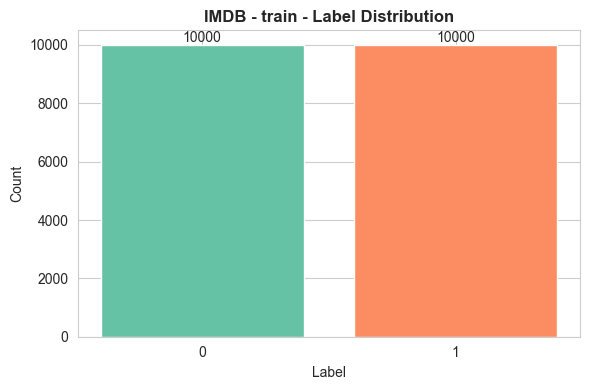

train: {0: 10000, 1: 10000}


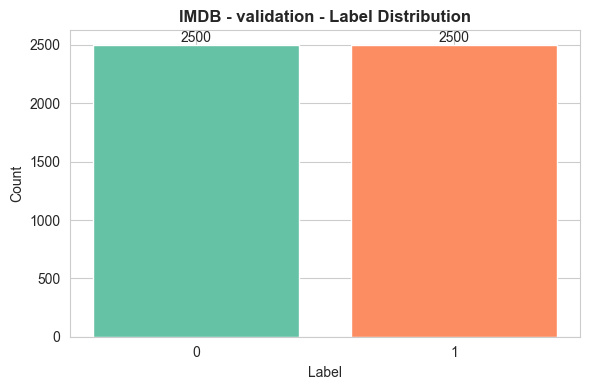

validation: {0: 2500, 1: 2500}


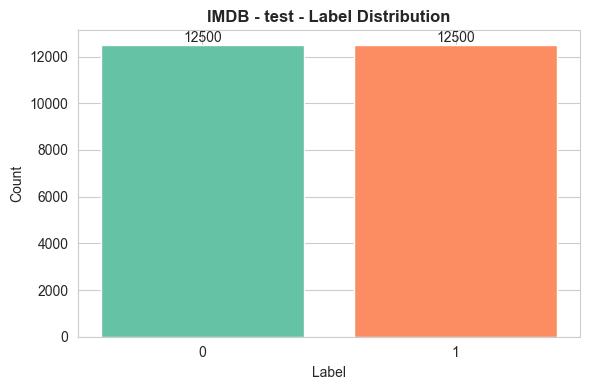

test: {0: 12500, 1: 12500}


In [8]:
for split_name, df in splits.items():
    if LABEL_COLUMN not in df.columns or not df[LABEL_COLUMN].notna().any():
        continue

    counts = df[LABEL_COLUMN].value_counts().sort_index()
    colors = sns.color_palette("Set2", len(counts))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(counts.index.astype(str), counts.values, color=colors)
    for i, (idx, v) in enumerate(counts.items()):
        ax.text(i, v + max(counts) * 0.01, str(v), ha="center", fontsize=10)
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.set_title(f"{DATASET} - {split_name} - Label Distribution", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(EDA_DIR, f"label_distribution_{split_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"{split_name}: {counts.to_dict()}")

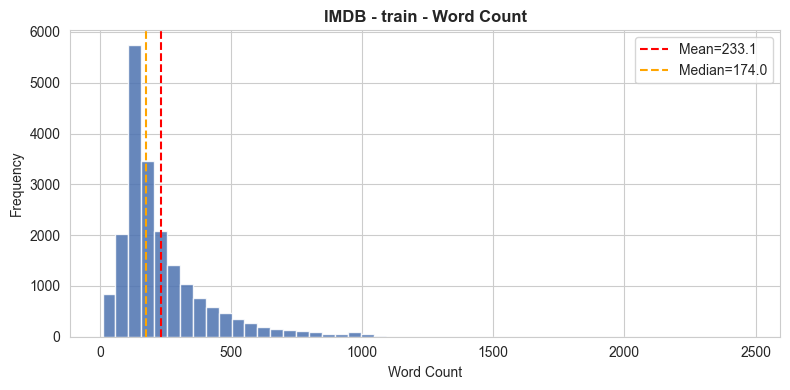

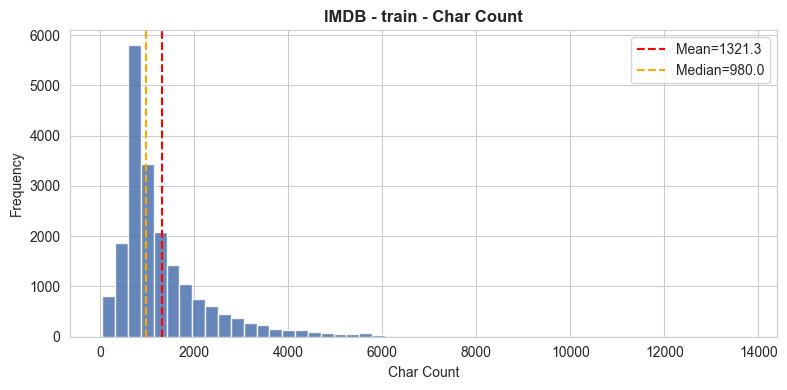

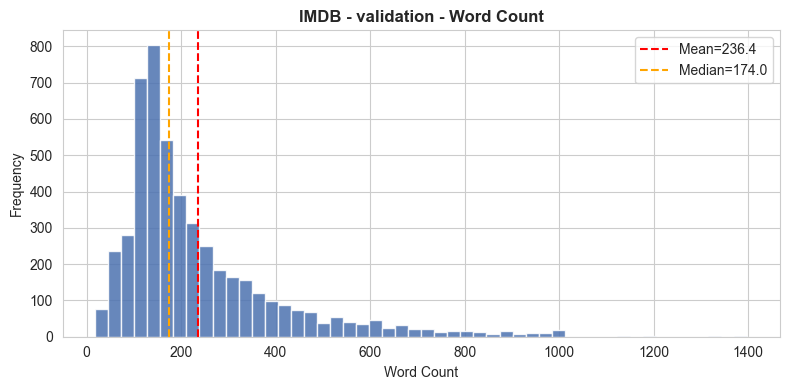

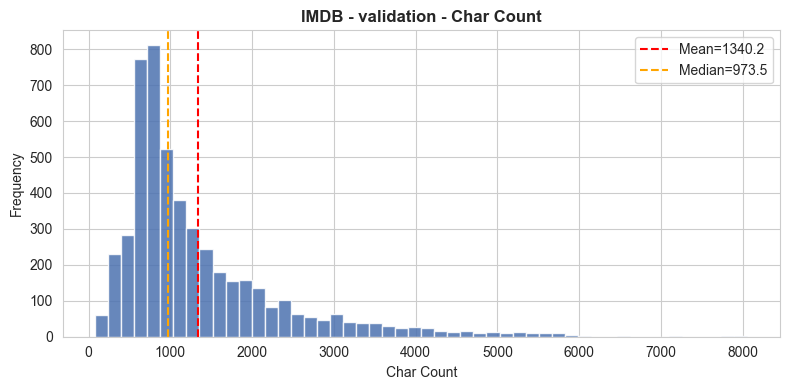

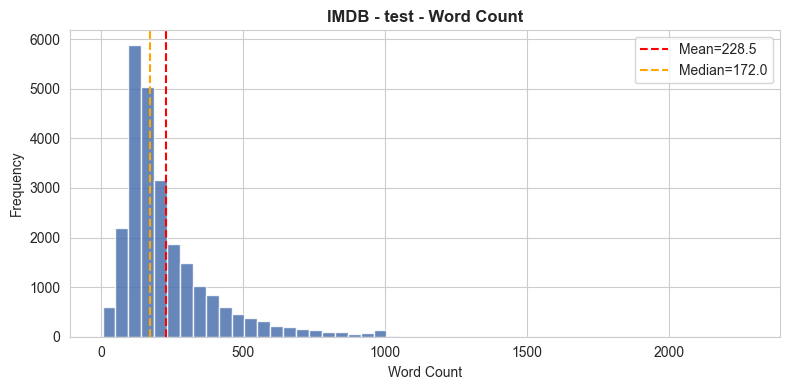

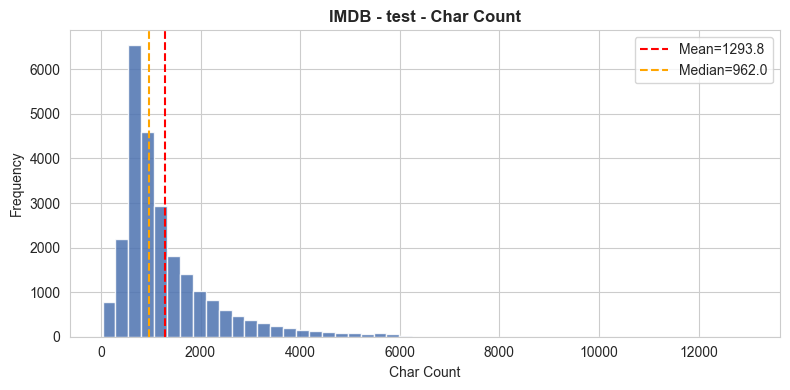

In [9]:
for split_name, df in splits.items():
    for col, xlabel in [("word_count", "Word Count"), ("char_count", "Char Count")]:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(df[col], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
        ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean={df[col].mean():.1f}")
        ax.axvline(df[col].median(), color="orange", linestyle="--", label=f"Median={df[col].median():.1f}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frequency")
        ax.set_title(f"{DATASET} - {split_name} - {xlabel}", fontweight="bold")
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(EDA_DIR, f"{col}_hist_{split_name}.png"), dpi=150, bbox_inches="tight")
        plt.show()

IMDB | train | Word Count | Label 0
  25%  = 128.00
  50%  = 175.00
  75%  = 277.25
  100% = 1522.00
--------------------------------------------------
IMDB | train | Word Count | Label 1
  25%  = 125.00
  50%  = 174.00
  75%  = 289.00
  100% = 2470.00
--------------------------------------------------


C:\Users\cemil\AppData\Local\Temp\ipykernel_25036\52732672.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


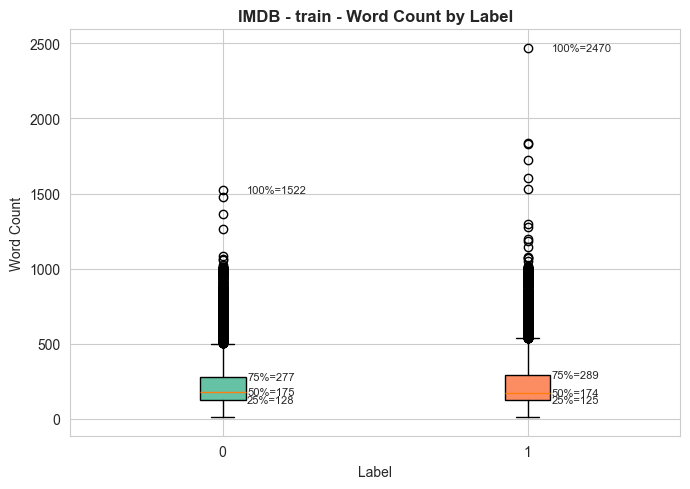

C:\Users\cemil\AppData\Local\Temp\ipykernel_25036\52732672.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


IMDB | train | Char Count | Label 0
  25%  = 707.00
  50%  = 978.00
  75%  = 1565.25
  100% = 8969.00
--------------------------------------------------
IMDB | train | Char Count | Label 1
  25%  = 695.00
  50%  = 981.00
  75%  = 1641.00
  100% = 13704.00
--------------------------------------------------


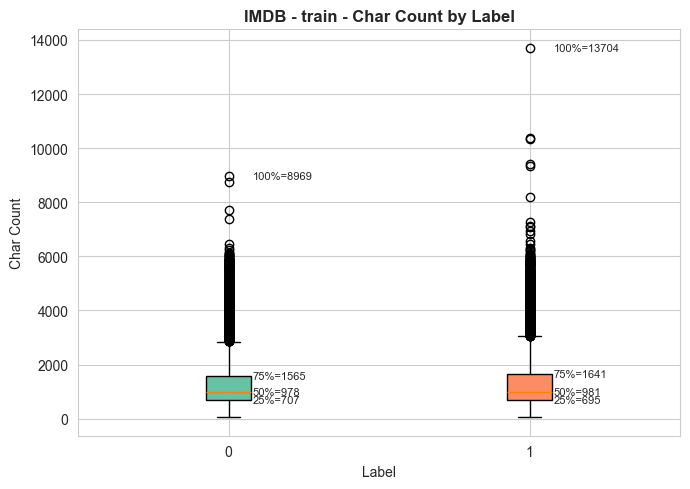

C:\Users\cemil\AppData\Local\Temp\ipykernel_25036\52732672.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


IMDB | validation | Word Count | Label 0
  25%  = 128.00
  50%  = 173.00
  75%  = 281.25
  100% = 1376.00
--------------------------------------------------
IMDB | validation | Word Count | Label 1
  25%  = 126.00
  50%  = 175.50
  75%  = 296.25
  100% = 1398.00
--------------------------------------------------


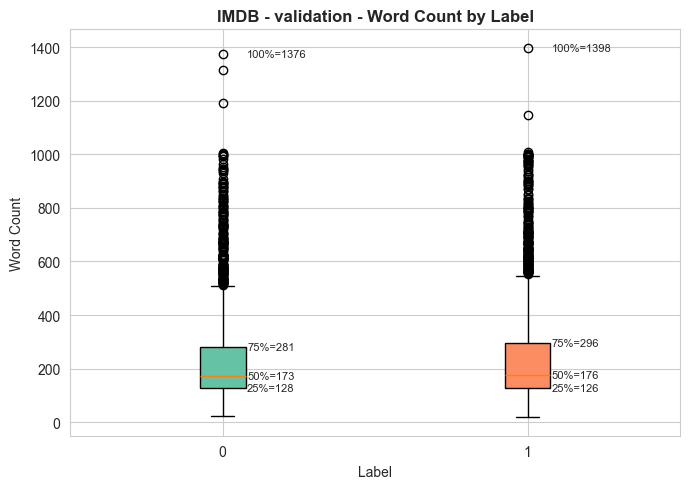

C:\Users\cemil\AppData\Local\Temp\ipykernel_25036\52732672.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


IMDB | validation | Char Count | Label 0
  25%  = 715.00
  50%  = 968.50
  75%  = 1581.25
  100% = 7761.00
--------------------------------------------------
IMDB | validation | Char Count | Label 1
  25%  = 694.75
  50%  = 983.50
  75%  = 1700.50
  100% = 8056.00
--------------------------------------------------


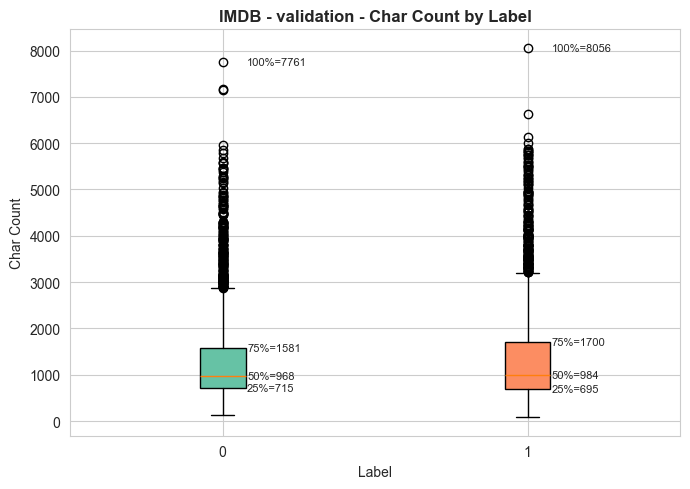

C:\Users\cemil\AppData\Local\Temp\ipykernel_25036\52732672.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


IMDB | test | Word Count | Label 0
  25%  = 127.00
  50%  = 173.50
  75%  = 278.00
  100% = 1090.00
--------------------------------------------------
IMDB | test | Word Count | Label 1
  25%  = 124.00
  50%  = 170.00
  75%  = 276.00
  100% = 2278.00
--------------------------------------------------


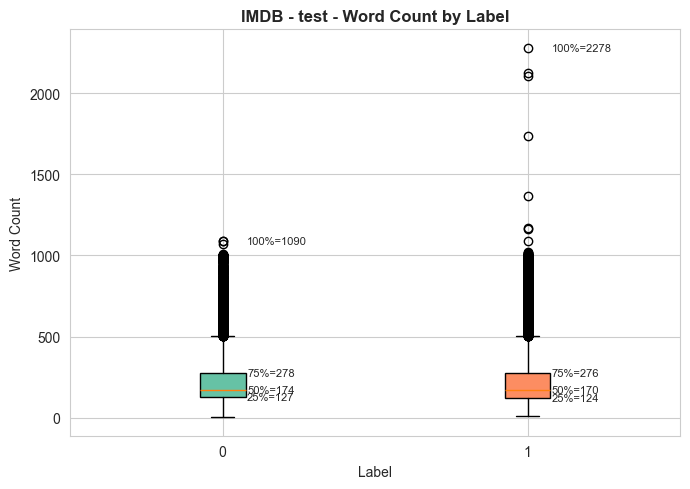

C:\Users\cemil\AppData\Local\Temp\ipykernel_25036\52732672.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


IMDB | test | Char Count | Label 0
  25%  = 703.00
  50%  = 970.00
  75%  = 1566.00
  100% = 6385.00
--------------------------------------------------
IMDB | test | Char Count | Label 1
  25%  = 688.00
  50%  = 954.00
  75%  = 1577.50
  100% = 12988.00
--------------------------------------------------


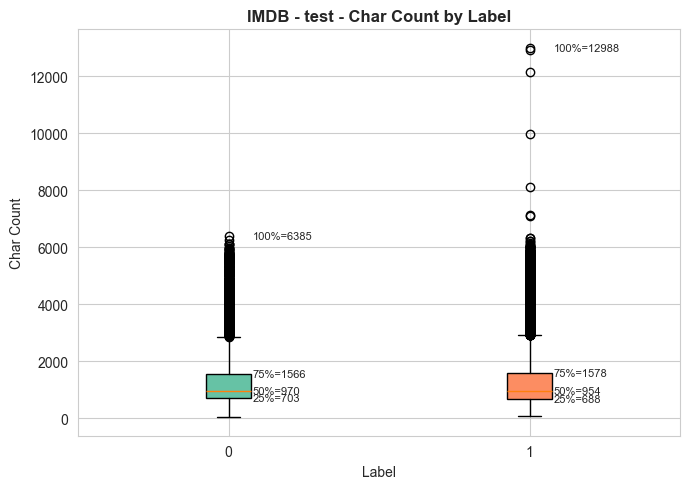

In [10]:
for split_name, df in splits.items():
    if LABEL_COLUMN not in df.columns or not df[LABEL_COLUMN].notna().any():
        continue

    labels_unique = sorted(df[LABEL_COLUMN].unique())
    colors = sns.color_palette("Set2", len(labels_unique))

    for col, xlabel in [("word_count", "Word Count"), ("char_count", "Char Count")]:
        data_groups = [df[df[LABEL_COLUMN] == lbl][col].dropna().values for lbl in labels_unique]

        fig, ax = plt.subplots(figsize=(7, 5))
        bp = ax.boxplot(
            data_groups,
            labels=[str(l) for l in labels_unique],
            patch_artist=True
        )

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)

        ax.set_xlabel("Label")
        ax.set_ylabel(xlabel)
        ax.set_title(f"{DATASET} - {split_name} - {xlabel} by Label", fontweight="bold")

        for i, vals in enumerate(data_groups, start=1):
            p25 = np.percentile(vals, 25)
            p50 = np.percentile(vals, 50)
            p75 = np.percentile(vals, 75)
            p100 = np.percentile(vals, 100)

            x_text = i + 0.08

            ax.text(x_text, p25,  f"25%={p25:.0f}", fontsize=8, va="center")
            ax.text(x_text, p50,  f"50%={p50:.0f}", fontsize=8, va="center")
            ax.text(x_text, p75,  f"75%={p75:.0f}", fontsize=8, va="center")
            ax.text(x_text, p100, f"100%={p100:.0f}", fontsize=8, va="center")

            print(f"{DATASET} | {split_name} | {xlabel} | Label {labels_unique[i-1]}")
            print(f"  25%  = {p25:.2f}")
            print(f"  50%  = {p50:.2f}")
            print(f"  75%  = {p75:.2f}")
            print(f"  100% = {p100:.2f}")
            print("-" * 50)

        fig.tight_layout()
        fig.savefig(os.path.join(EDA_DIR, f"boxplot_{col}_by_label_{split_name}.png"), dpi=150, bbox_inches="tight")
        plt.show()

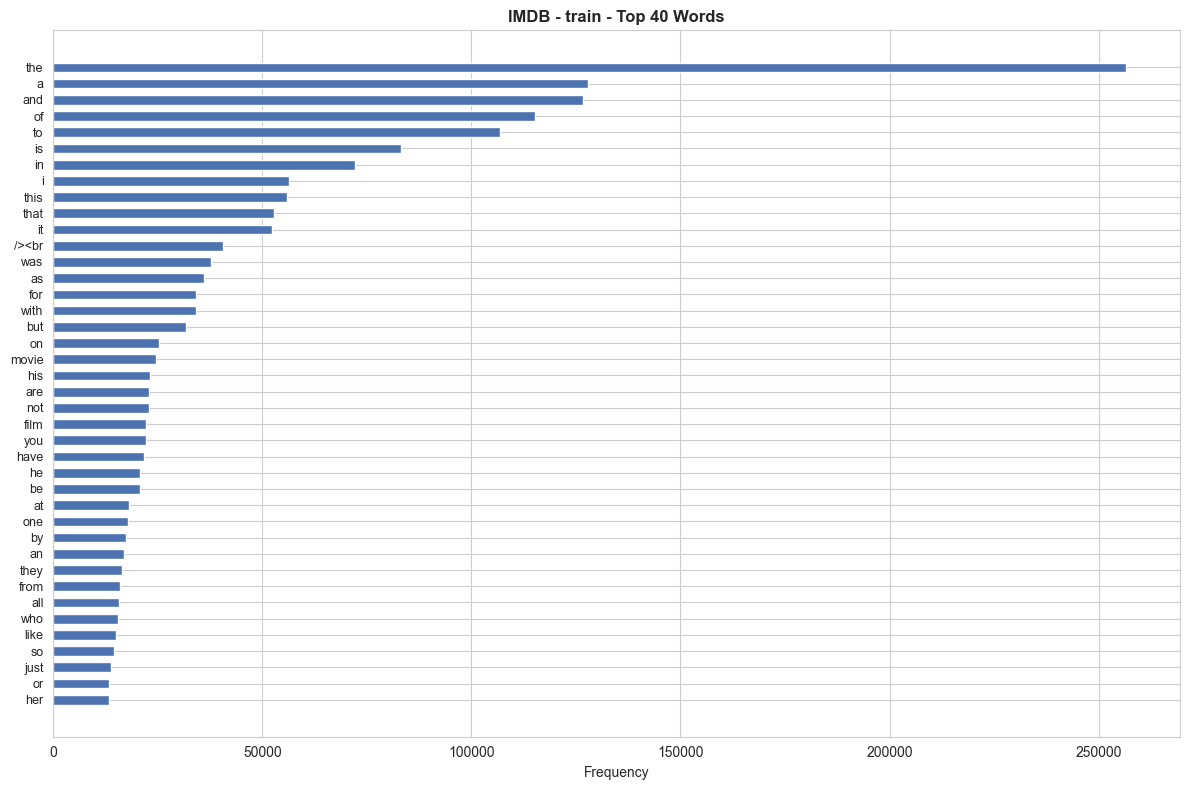

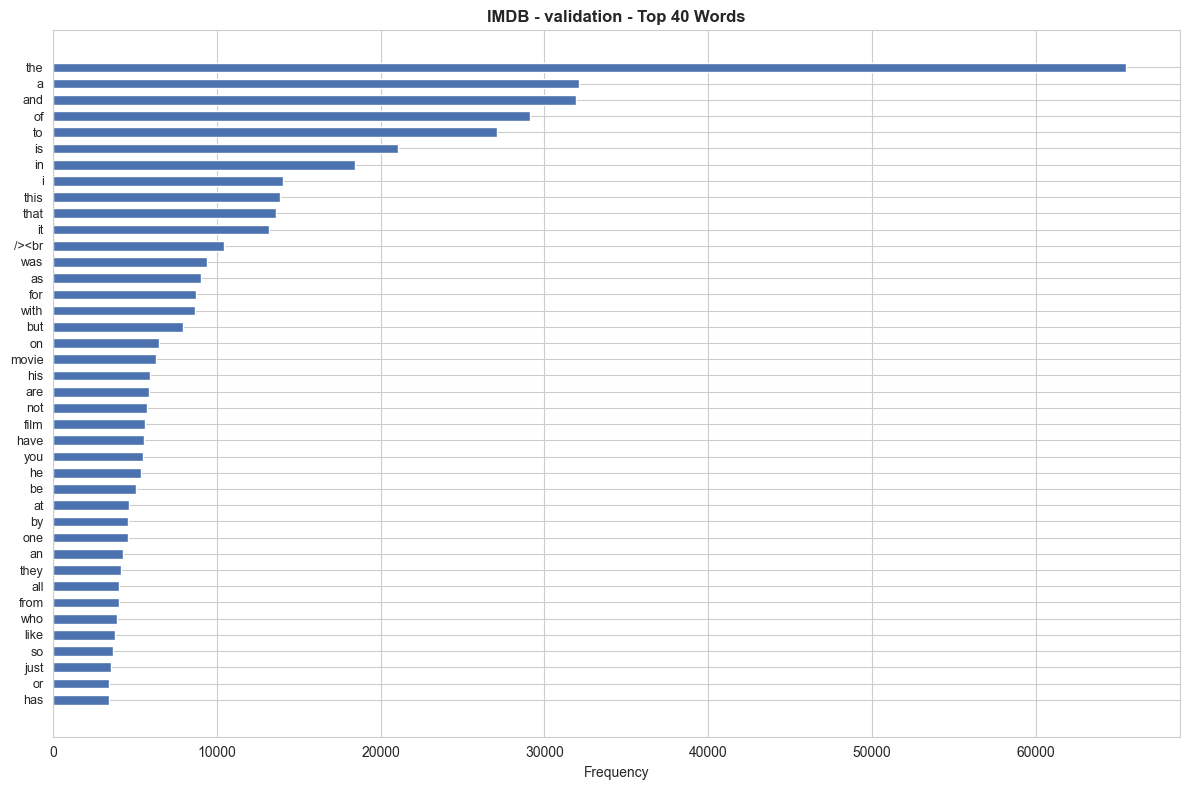

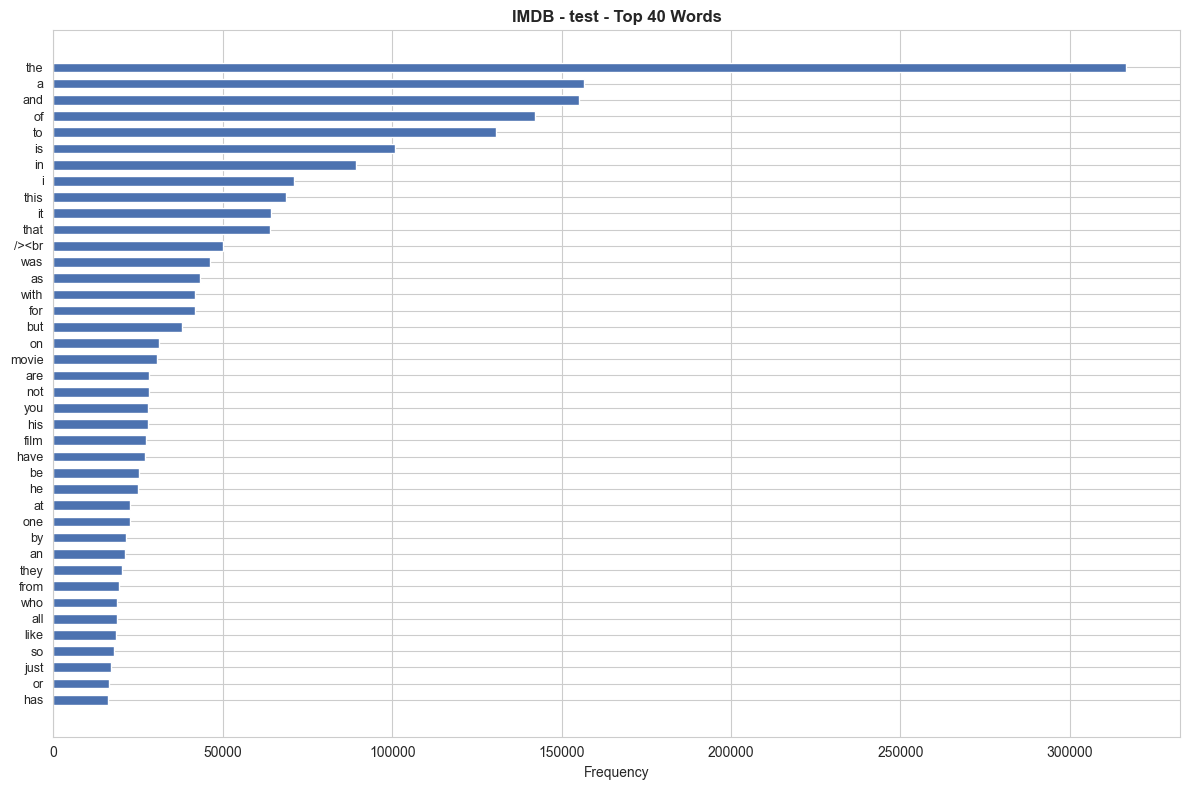

In [11]:
TOP_N = 40

for split_name, df in splits.items():
    all_words = " ".join(df[TEXT_COLUMN].astype(str).tolist()).lower().split()
    counter = Counter(all_words)
    most_common = counter.most_common(TOP_N)
    words, freqs = zip(*most_common)

    fig_height = TOP_N * 0.2
    fig, ax = plt.subplots(figsize=(12, fig_height))
    ax.barh(range(len(words)), freqs, height=0.6, color="#4C72B0")
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Frequency")
    ax.set_title(f"{DATASET} - {split_name} - Top {TOP_N} Words", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(EDA_DIR, f"top_words_{split_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

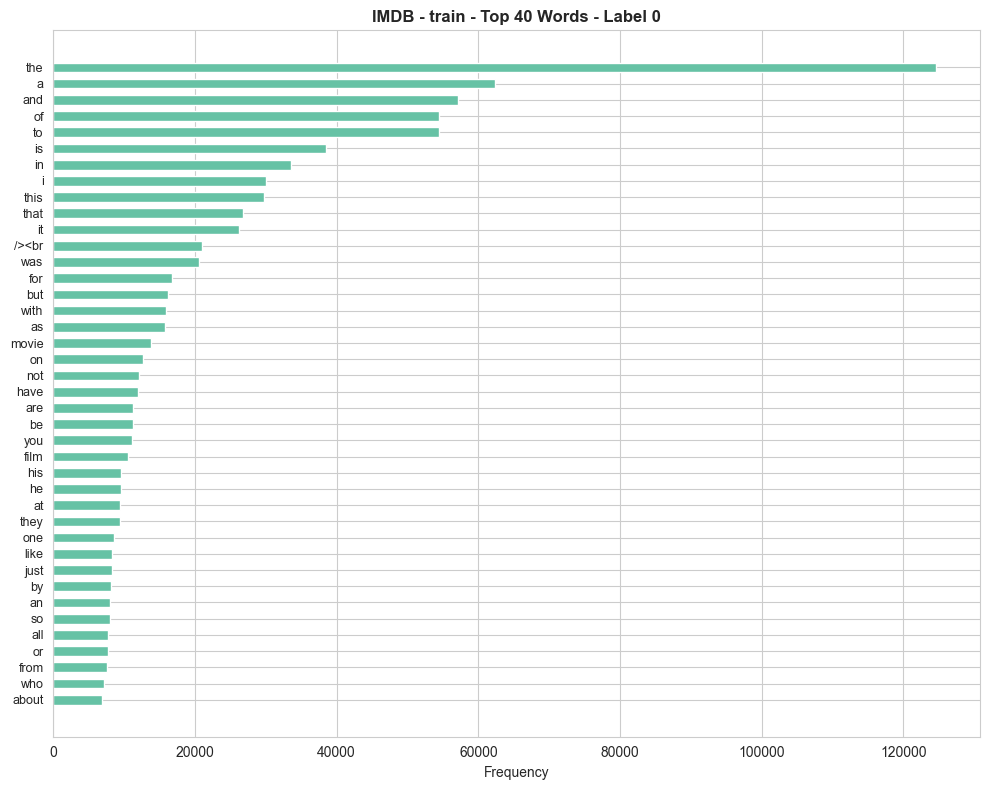

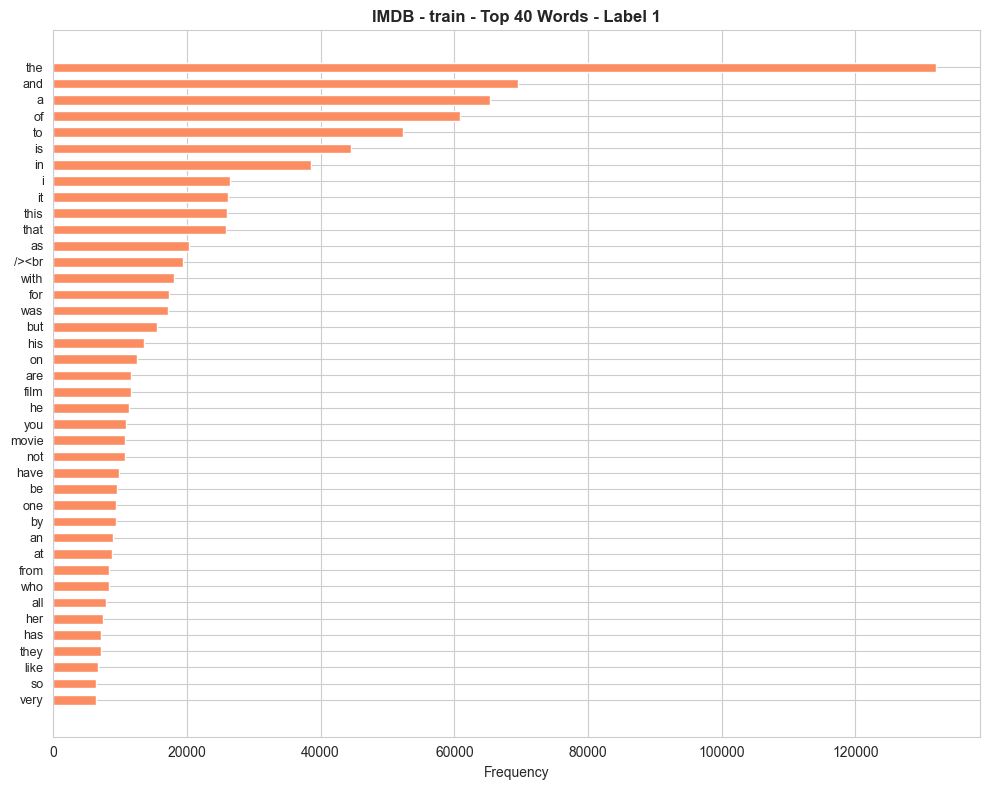

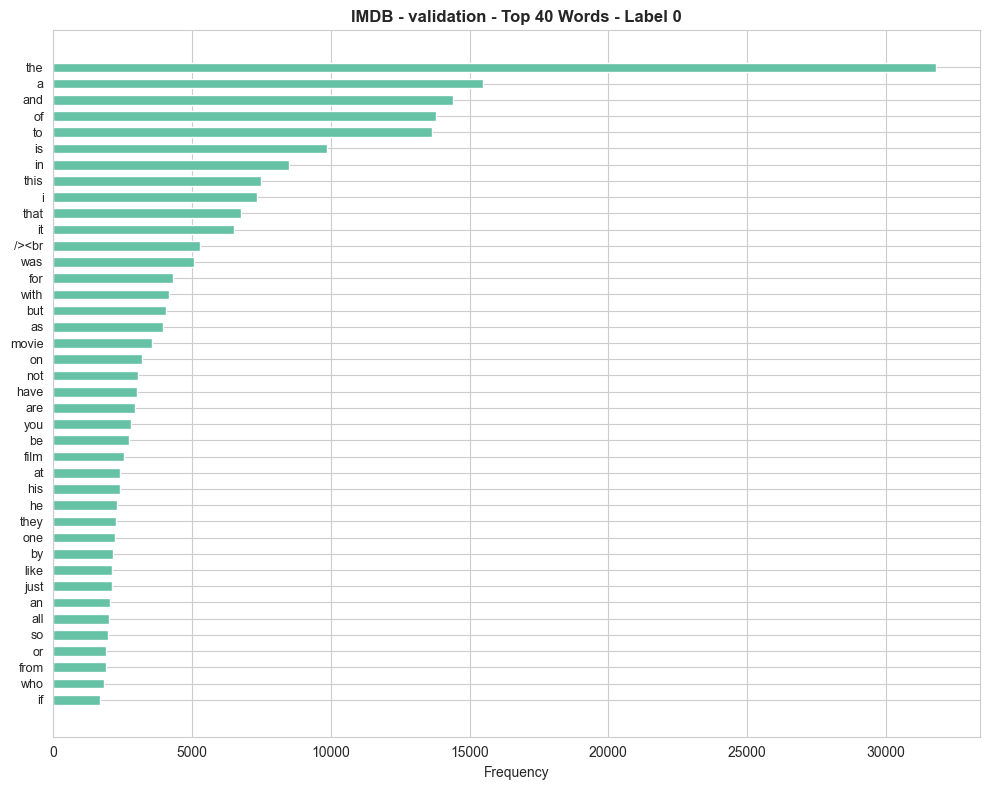

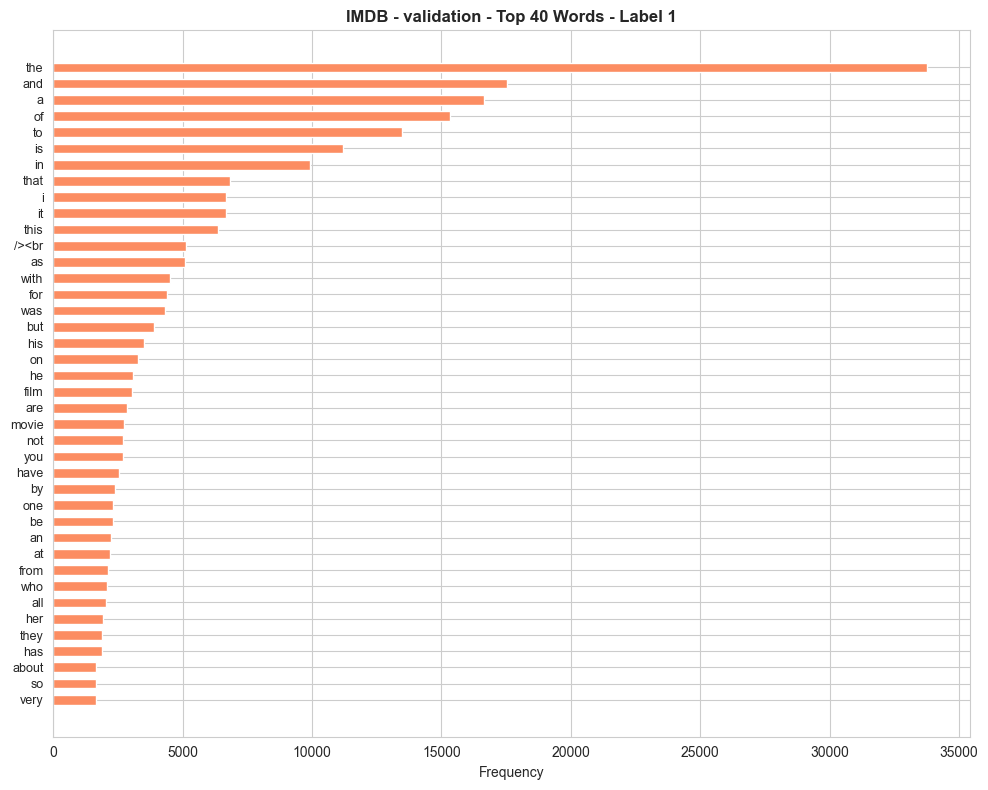

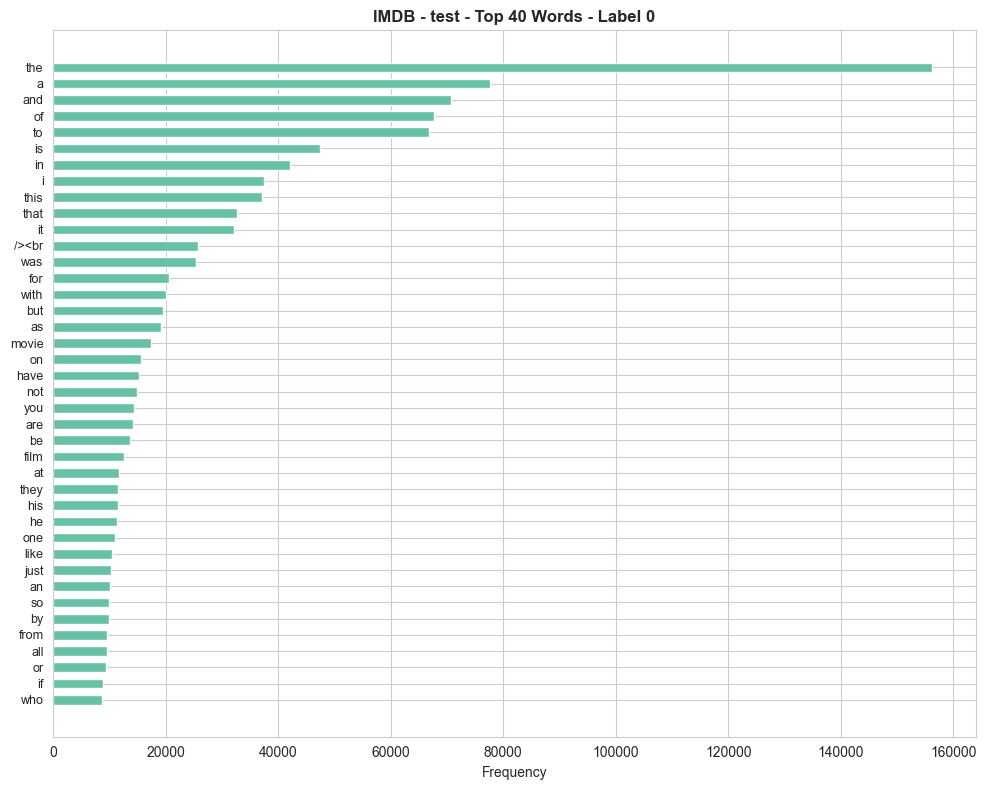

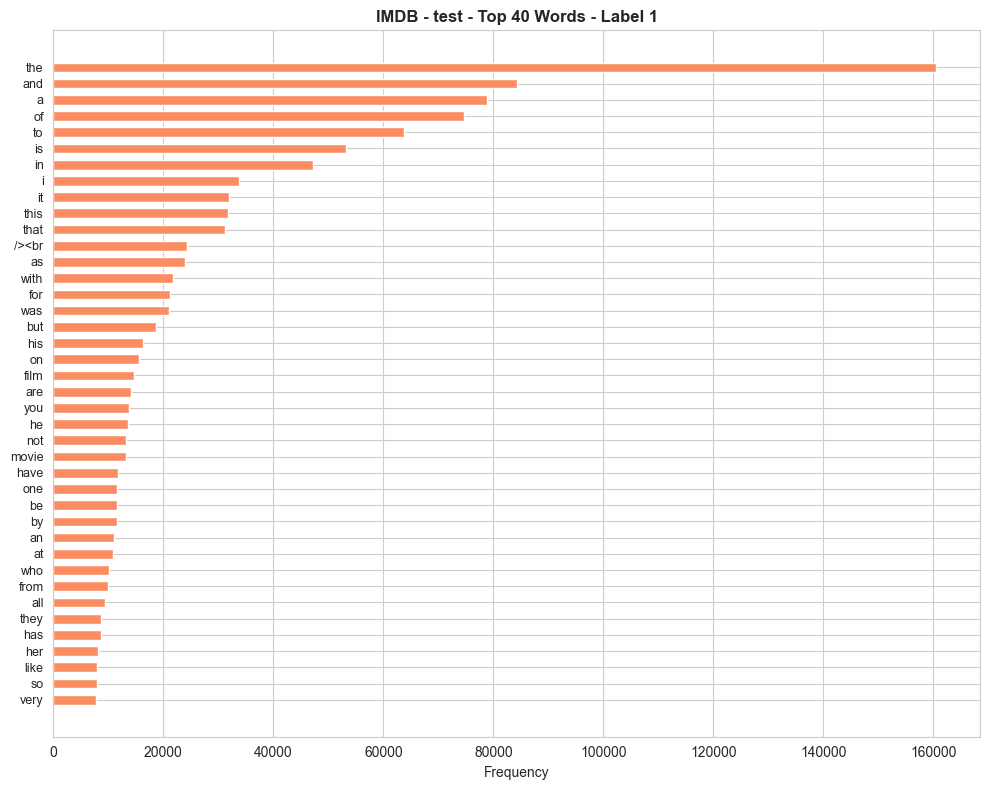

In [12]:
TOP_N_PER_LABEL = 40

for split_name, df in splits.items():
    if LABEL_COLUMN not in df.columns or not df[LABEL_COLUMN].notna().any():
        continue

    labels_unique = sorted(df[LABEL_COLUMN].unique())
    colors = sns.color_palette("Set2", len(labels_unique))

    for i, lbl in enumerate(labels_unique):
        subset = df[df[LABEL_COLUMN] == lbl]
        all_words = " ".join(subset[TEXT_COLUMN].astype(str).tolist()).lower().split()
        counter = Counter(all_words)
        most_common = counter.most_common(TOP_N_PER_LABEL)
        if not most_common:
            continue
        words, freqs = zip(*most_common)

        fig_height = TOP_N_PER_LABEL * 0.2
        fig, ax = plt.subplots(figsize=(10, fig_height))
        ax.barh(range(len(words)), freqs, height=0.6, color=colors[i])
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Frequency")
        ax.set_title(f"{DATASET} - {split_name} - Top {TOP_N_PER_LABEL} Words - Label {lbl}", fontweight="bold")
        fig.tight_layout()
        fig.savefig(os.path.join(EDA_DIR, f"top_words_label{lbl}_{split_name}.png"), dpi=150, bbox_inches="tight")
        plt.show()

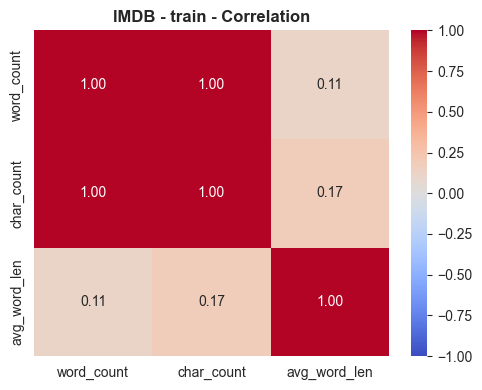

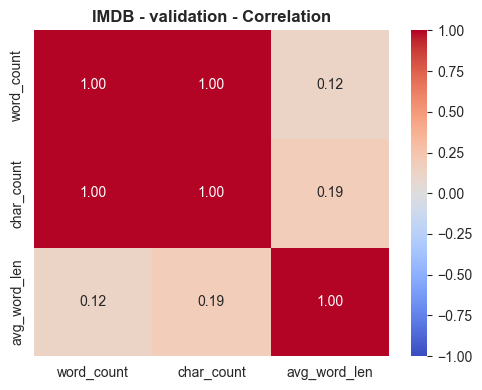

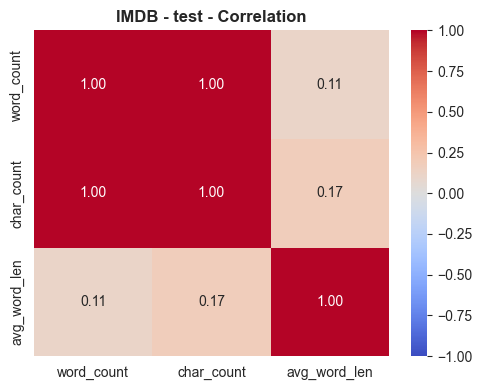

In [13]:
for split_name, df in splits.items():
    num_cols = [c for c in ("word_count", "char_count", "avg_word_len") if c in df.columns]
    if len(num_cols) < 2:
        continue

    corr = df[num_cols].corr()

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
    ax.set_title(f"{DATASET} - {split_name} - Correlation", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(EDA_DIR, f"correlation_{split_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

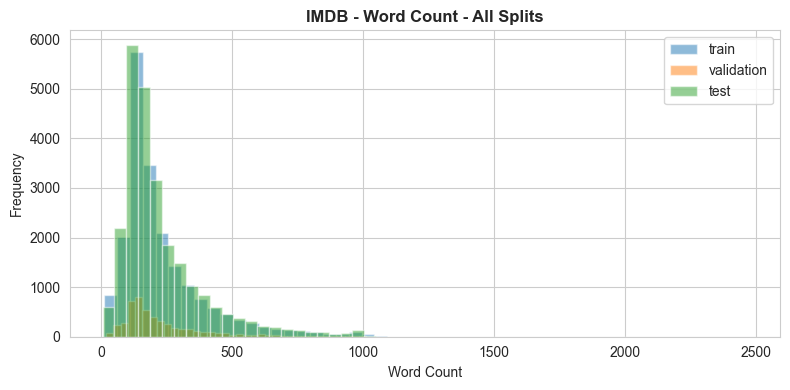

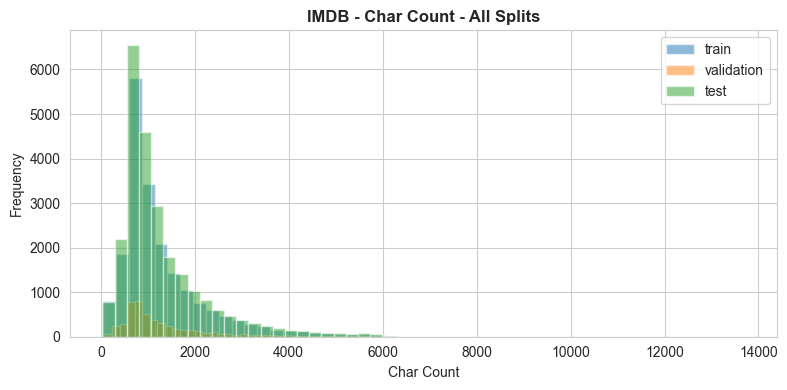

In [14]:
split_colors = {"train": "#1f77b4", "validation": "#ff7f0e", "test": "#2ca02c"}

for col, xlabel in [("word_count", "Word Count"), ("char_count", "Char Count")]:
    fig, ax = plt.subplots(figsize=(8, 4))
    for split_name, df in splits.items():
        ax.hist(df[col], bins=50, alpha=0.5, label=split_name, color=split_colors.get(split_name))
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{DATASET} - {xlabel} - All Splits", fontweight="bold")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(EDA_DIR, f"{col}_all_splits.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [15]:
for split_name, df in splits.items():
    dups = df[df.duplicated(subset=[TEXT_COLUMN], keep=False)]
    print(f"\n--- {split_name} -- {len(dups)} duplicate rows ---")
    if len(dups) > 0:
        display(dups[[TEXT_COLUMN, LABEL_COLUMN]].head(10))

    shortest = df.nsmallest(5, "word_count")[[TEXT_COLUMN, "word_count"]]
    longest = df.nlargest(5, "word_count")[[TEXT_COLUMN, "word_count"]]
    print(f"\n  Top 5 shortest:")
    display(shortest)
    print(f"\n  Top 5 longest:")
    display(longest)


--- train -- 117 duplicate rows ---


,text_original,label
27,"in this movie, joe pesci slams dunks a basketb...",0
209,Bette Midler is indescribable in this concert....,1
222,This was one of the lamest movies we watched i...,0
275,"Sondra Locke stinks in this film, but then she...",0
377,I really enjoyed this movie. The script is fre...,1
427,"The '60s is an occasionally entertaining film,...",0
481,The 1960's were a time of change and awakening...,0
539,"Les Visiteurs, the first movie about the medie...",0
594,I watched this movie when Joe Bob Briggs hoste...,0
640,"In 1993, ""the visitors"" was an enormous hit in...",0



  Top 5 shortest:


,text_original,word_count
15773,This movie is terrible but it has some good ef...,10
18926,I wouldn't rent this one even on dollar rental...,10
13618,You'd better choose Paul Verhoeven's even if y...,11
6856,Ming The Merciless does a little Bardwork and ...,12
16252,Adrian Pasdar is excellent is this film. He ma...,12



  Top 5 longest:


...

,text_original,label
328,We were excited to rent this one after reading...,0
730,"This is by far the most vapid, idiotic, insane...",0
731,Tyra Banks needs to teach these girls that it'...,0
732,"In watching this off and on for a few seasons,...",0
733,Tyra & the rest of the modeling world needs to...,0
734,I would like to comment on how the girls are c...,0
1012,Sigh. I'm baffled when I see a short like this...,0
1014,Sigh. I'm baffled when I see a short like this...,0
1420,The first time I had heard of Guest House Pari...,0
1421,Possibly the worst film within the genre in ex...,0



  Top 5 shortest:


,text_original,word_count
5220,Primary plot!Primary direction!Poor interpreta...,4
6845,"Read the book, forget the movie!",6
318,I hope this group of film-makers never re-unites.,8
8658,"More suspenseful, more subtle, much, much more...",8
6916,"What a script, what a story, what a mess!",9



  Top 5 longest:


,text_original,word_count
21132,There's a sign on The Lost Highway that says:<...,2278
16512,"Back in the mid/late 80s, an OAV anime by titl...",2125
16250,"(Some spoilers included:)<br /><br />Although,...",2108
13153,If anyone ever assembles a compendium on moder...,1737
16349,"Films belonging to the ""film noir"" genre usual...",1366


In [16]:
print(f"{'='*50}")
print(f"  Cross-Split Text Overlap (Data Leakage Check)")
print(f"{'='*50}")

split_names = list(splits.keys())
for i in range(len(split_names)):
    for j in range(i + 1, len(split_names)):
        name_a, name_b = split_names[i], split_names[j]
        texts_a = set(splits[name_a][TEXT_COLUMN].astype(str).tolist())
        texts_b = set(splits[name_b][TEXT_COLUMN].astype(str).tolist())
        overlap = texts_a & texts_b
        pct_a = len(overlap) / len(texts_a) * 100 if texts_a else 0
        pct_b = len(overlap) / len(texts_b) * 100 if texts_b else 0

        print(f"\n  {name_a} ∩ {name_b}: {len(overlap)} shared texts")
        print(f"    = {pct_a:.2f}% of {name_a} ({len(texts_a)} unique)")
        print(f"    = {pct_b:.2f}% of {name_b} ({len(texts_b)} unique)")

        if len(overlap) > 0:
            print(f"    ⚠ DATA LEAKAGE DETECTED!")
            examples = list(overlap)[:3]
            for ex in examples:
                print(f"      • \"{ex[:80]}{'...' if len(ex) > 80 else ''}\"")
        else:
            print(f"    ✓ No leakage")

  Cross-Split Text Overlap (Data Leakage Check)

  train ∩ validation: 34 shared texts
    = 0.17% of train (19941 unique)
    = 0.68% of validation (4997 unique)
    ⚠ DATA LEAKAGE DETECTED!
      • "A have a female friend who is currently being drawn into a relationship with an ..."
      • "There is no reason to see this movie. A good plot idea is handled very badly. In..."
      • "I like a lot of the actors/actresses involved in this project so being insulted ..."

  train ∩ test: 99 shared texts
    = 0.50% of train (19941 unique)
    = 0.40% of test (24801 unique)
    ⚠ DATA LEAKAGE DETECTED!
      • "After all these years, of Peter O'Tool's brilliant, costly giving of his Soul, f..."
      • "1st watched 12/26/2008 -(Dir-Eugene Levy): Corny comedy murder mystery with very..."
      • "An updated version of a theme which has been done before. While that in and of i..."

  validation ∩ test: 24 shared texts
    = 0.48% of validation (4997 unique)
    = 0.10% of test (24801 unique

In [17]:
print(f"{'='*50}")
print(f"  Vocabulary Coverage")
print(f"{'='*50}")

if "train" in splits:
    train_vocab = set(" ".join(splits["train"][TEXT_COLUMN].astype(str).tolist()).lower().split())
    print(f"\n  Train vocabulary size: {len(train_vocab):,} unique words")

    for split_name in ["validation", "test"]:
        if split_name not in splits:
            continue
        split_vocab = set(" ".join(splits[split_name][TEXT_COLUMN].astype(str).tolist()).lower().split())
        covered = split_vocab & train_vocab
        oov = split_vocab - train_vocab
        coverage = len(covered) / len(split_vocab) * 100 if split_vocab else 0

        print(f"\n  {split_name} vocabulary size: {len(split_vocab):,} unique words")
        print(f"    Covered by train: {len(covered):,} ({coverage:.2f}%)")
        print(f"    Out-of-vocabulary: {len(oov):,} ({100 - coverage:.2f}%)")
        if oov:
            oov_examples = sorted(oov)[:10]
            print(f"    OOV examples: {oov_examples}")
else:
    print("  Train split not available.")

  Vocabulary Coverage

  Train vocabulary size: 219,169 unique words

  validation vocabulary size: 92,867 unique words
    Covered by train: 60,399 (65.04%)
    Out-of-vocabulary: 32,468 (34.96%)
    OOV examples: ['!!!!"', '!!!.<br', '!!)<br', '!!,', '!?!?!?!?!?', '""shin', '"&$*@$', '"\'menaikkan\'', '"\'son', '"\'spoiling\'']

  test vocabulary size: 247,630 unique words
    Covered by train: 101,126 (40.84%)
    Out-of-vocabulary: 146,504 (59.16%)
    OOV examples: ['!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!<br', '!!!!!!!!!<br', '!!!!!!!!.', '!!!!!(spoilers', '!!!!)', '!!!..', '!!!you', '!!)']


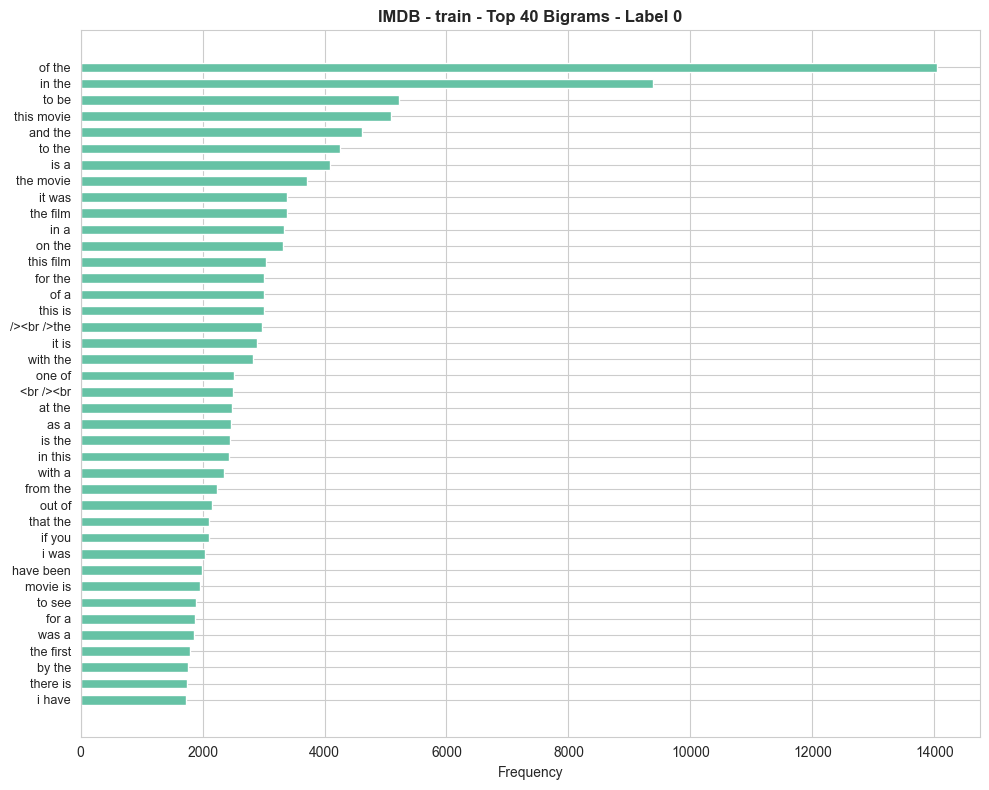

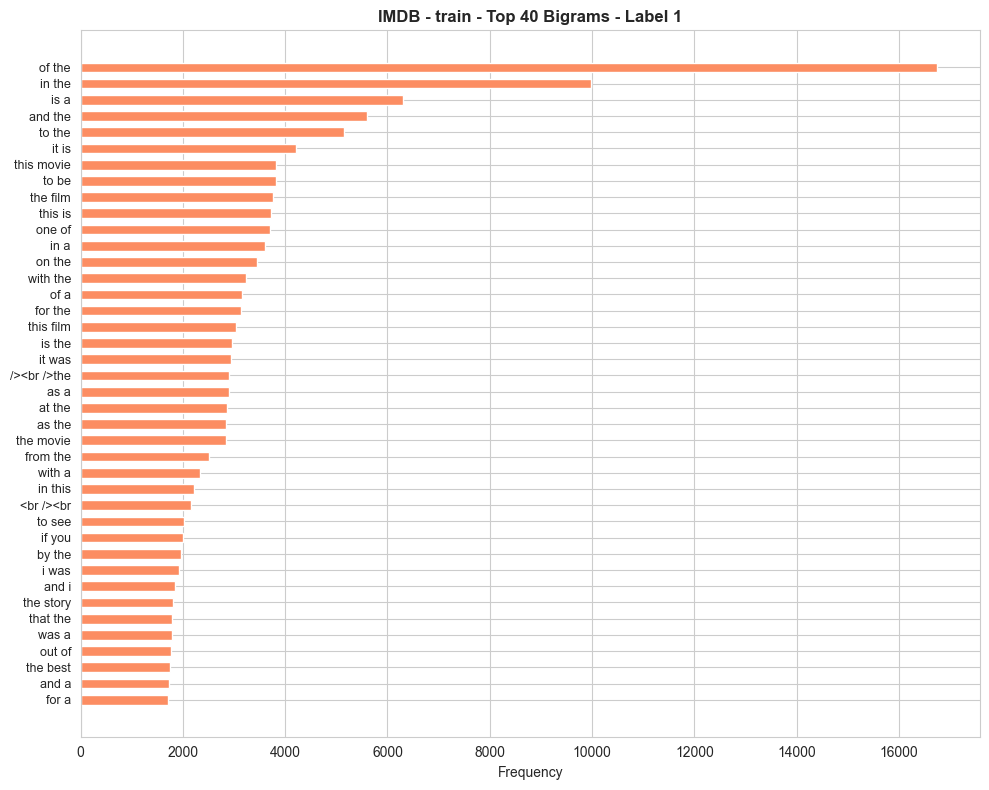

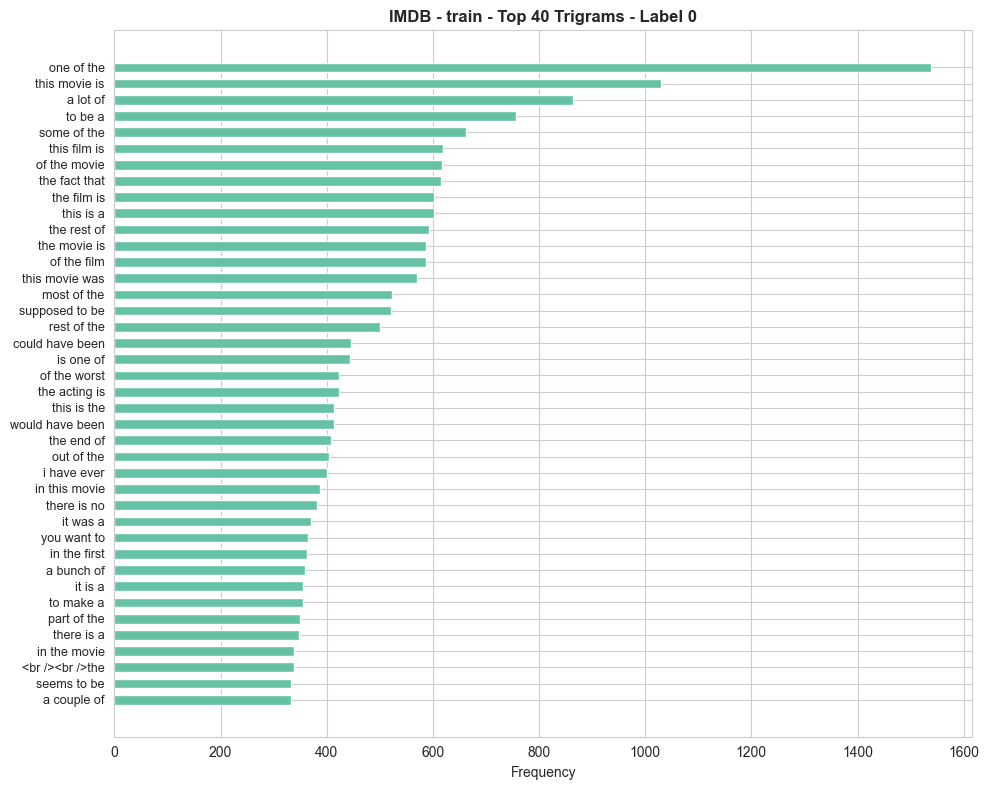

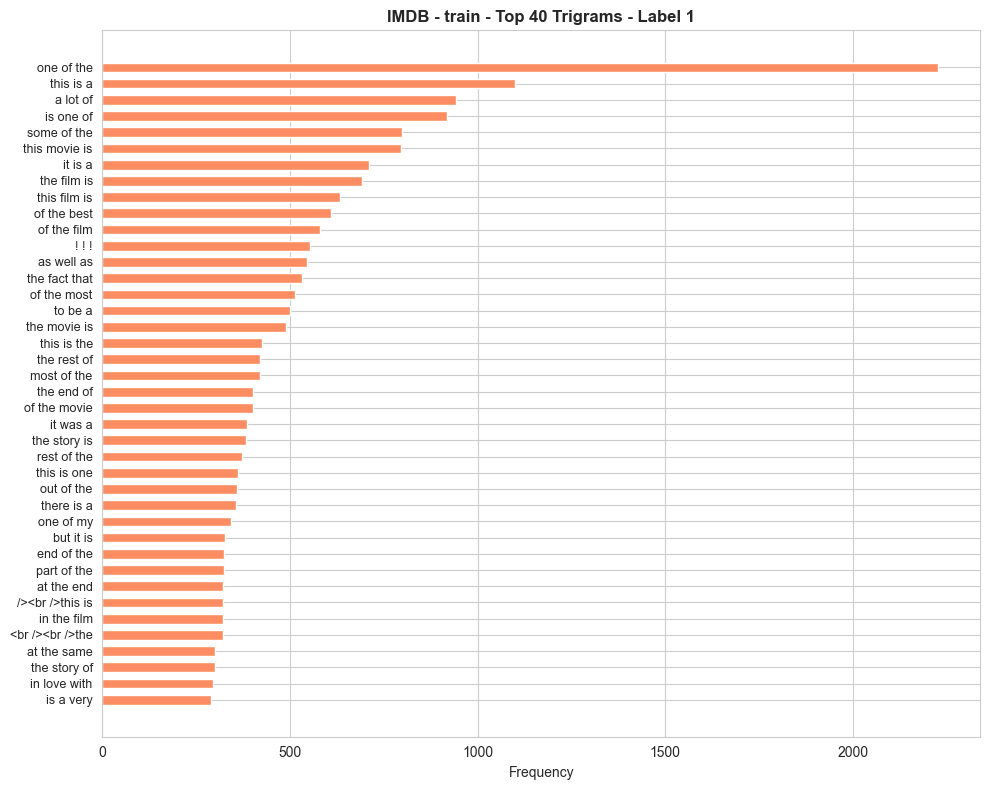

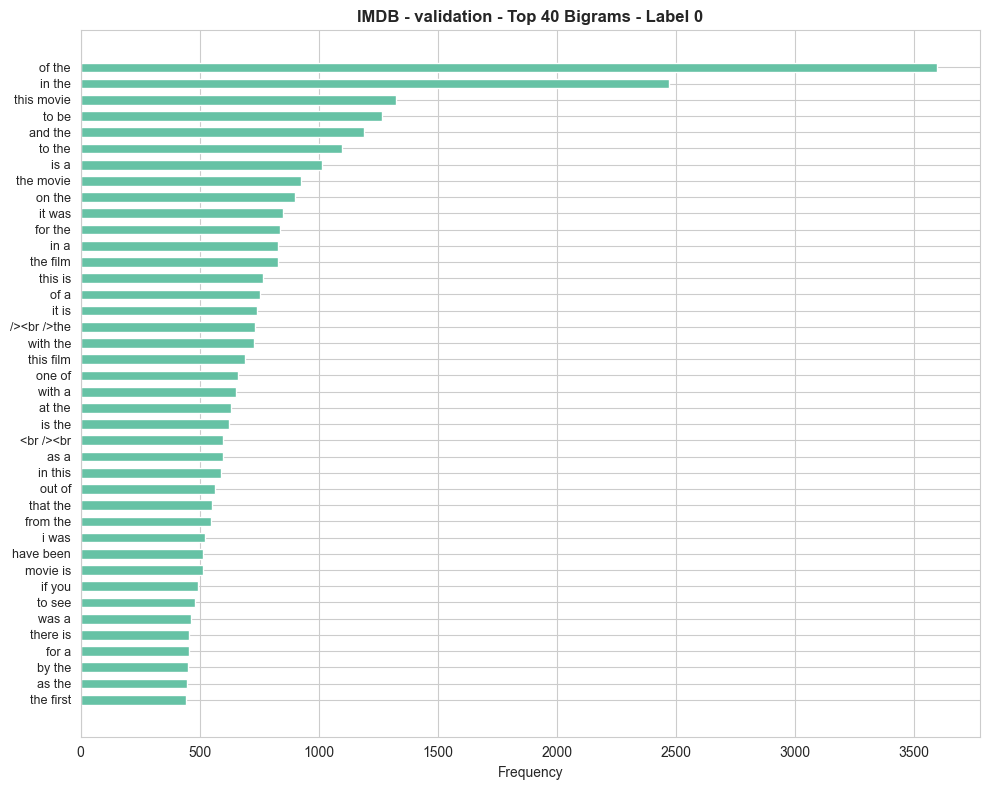

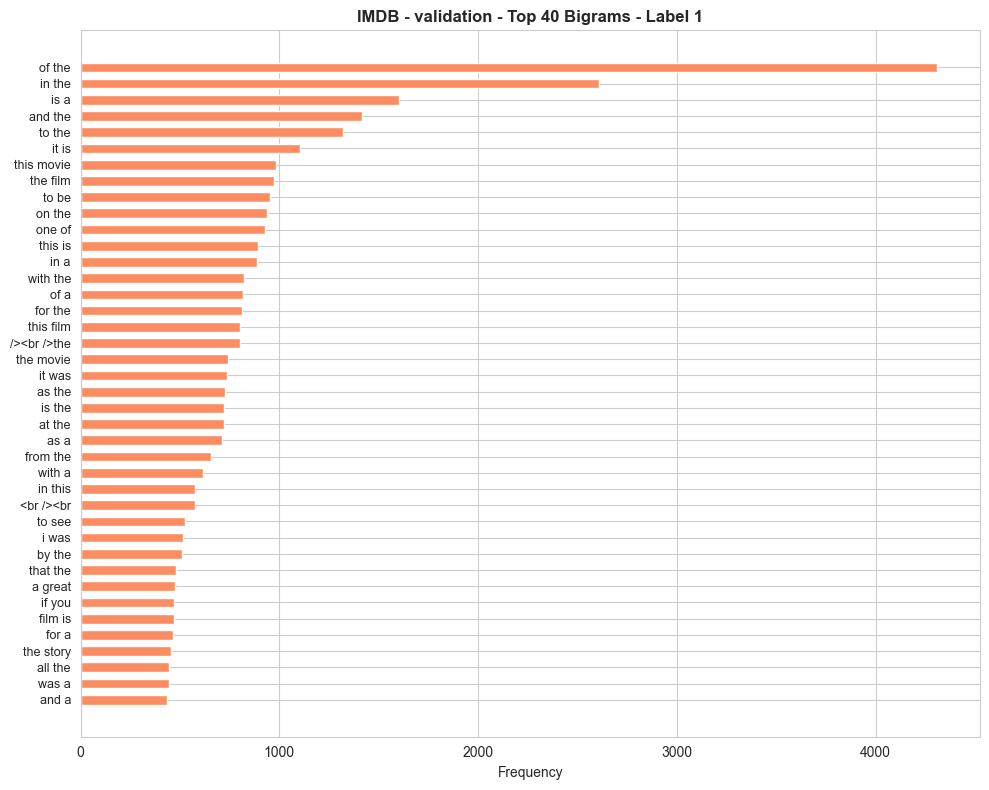

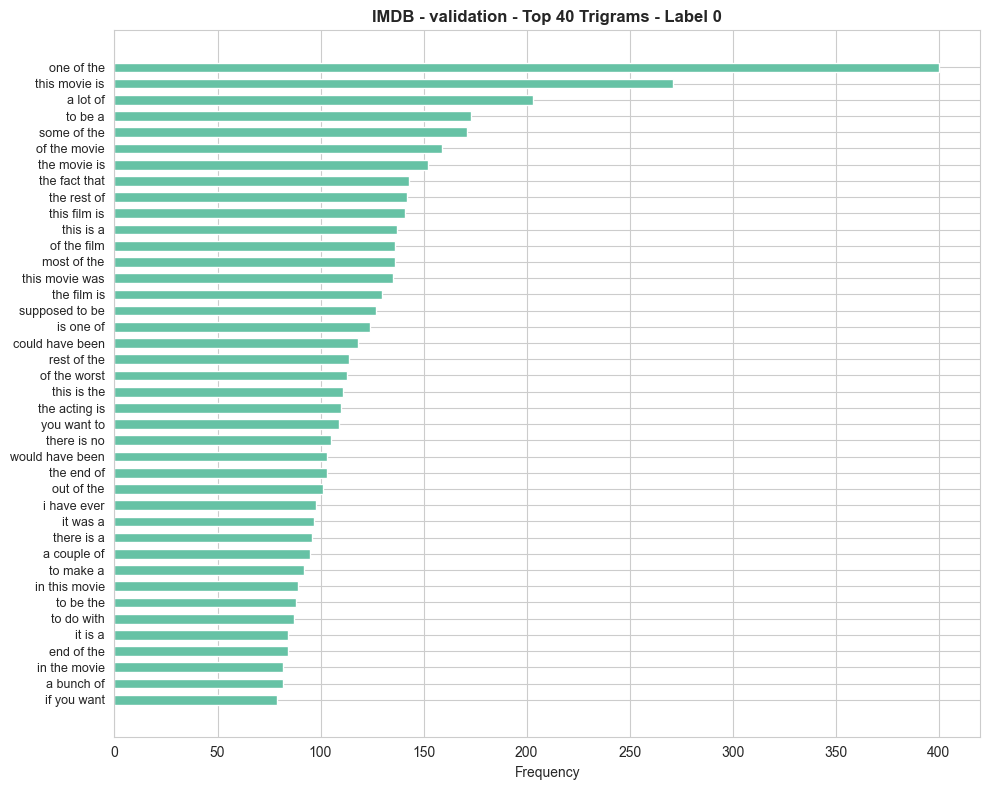

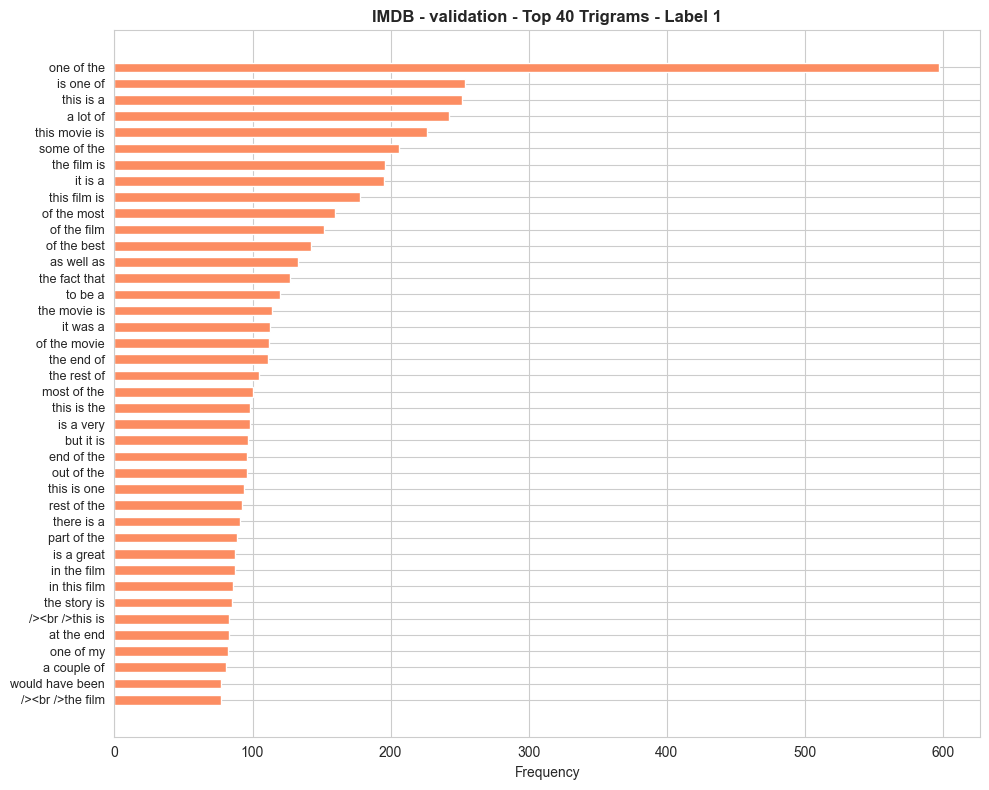

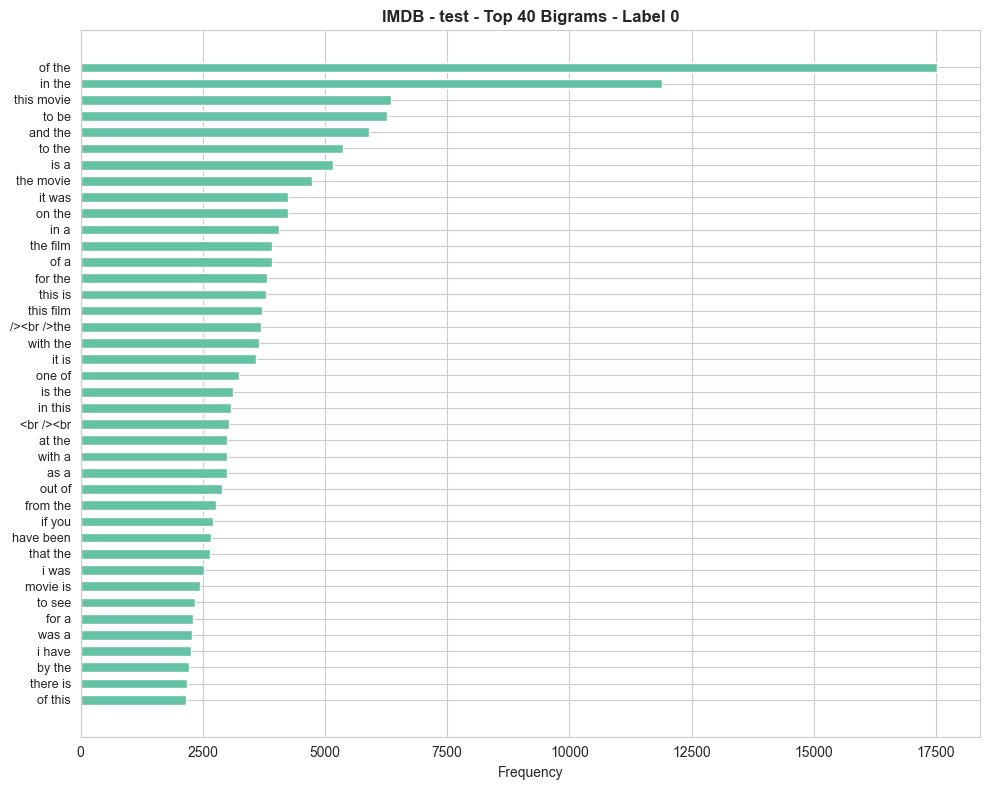

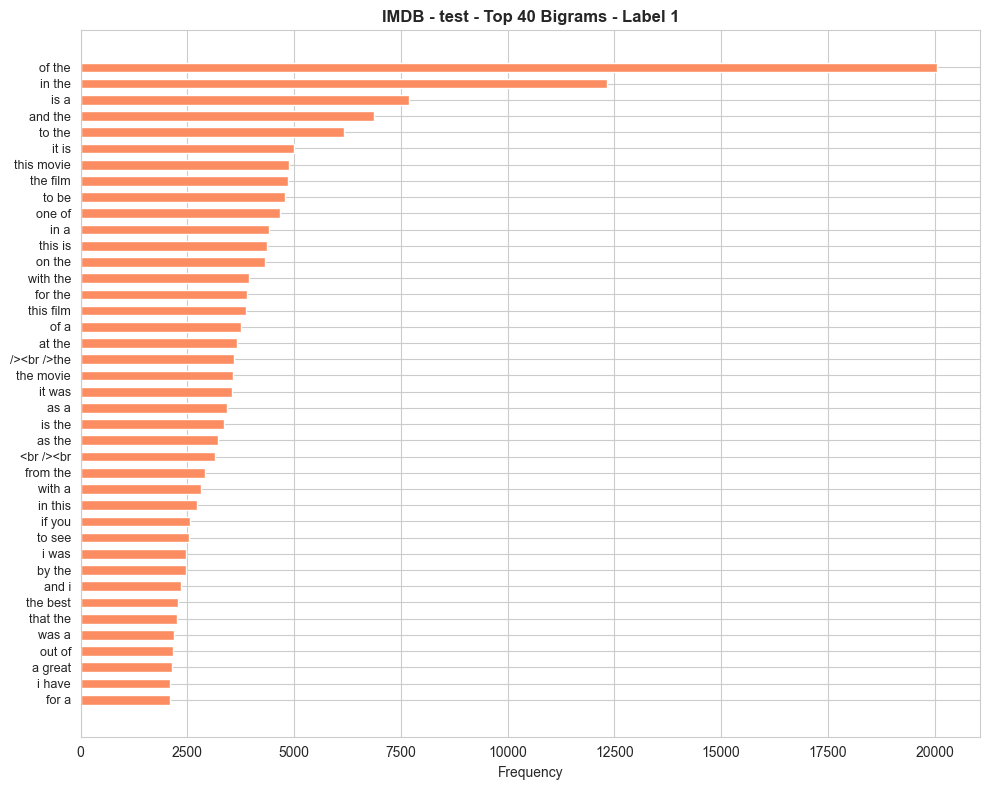

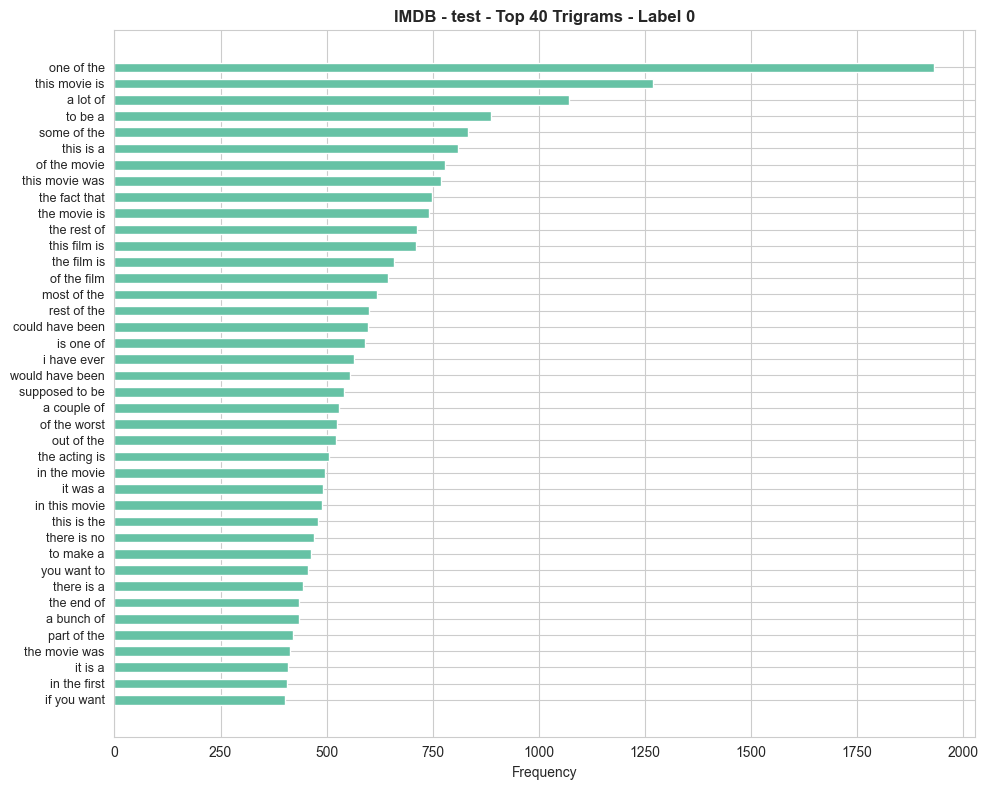

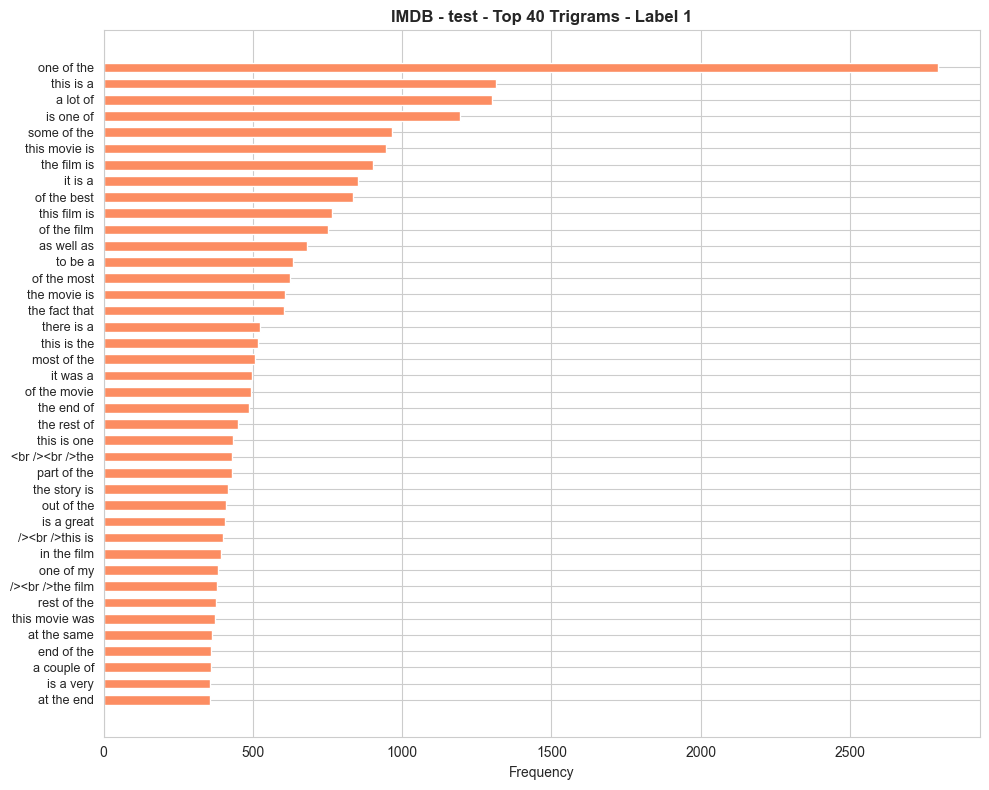

In [18]:
from itertools import islice

TOP_NGRAMS = 40

def get_ngrams(texts, n):
    ngrams = []
    for text in texts:
        words = str(text).lower().split()
        ngrams.extend(zip(*[words[i:] for i in range(n)]))
    return Counter(ngrams)

for split_name, df in splits.items():
    if LABEL_COLUMN not in df.columns or not df[LABEL_COLUMN].notna().any():
        continue

    labels_unique = sorted(df[LABEL_COLUMN].unique())
    n_labels = len(labels_unique)
    colors = sns.color_palette("Set2", n_labels)

    for n, ngram_name in [(2, "Bigrams"), (3, "Trigrams")]:
        for i, lbl in enumerate(labels_unique):
            subset = df[df[LABEL_COLUMN] == lbl]
            ngram_counts = get_ngrams(subset[TEXT_COLUMN].tolist(), n)
            most_common = ngram_counts.most_common(TOP_NGRAMS)
            if not most_common:
                continue
            labels_str = [" ".join(ng) for ng, _ in most_common]
            freqs = [f for _, f in most_common]

            fig_height = TOP_NGRAMS * 0.2
            fig, ax = plt.subplots(figsize=(10, fig_height))
            ax.barh(range(len(labels_str)), freqs, height=0.6, color=colors[i])
            ax.set_yticks(range(len(labels_str)))
            ax.set_yticklabels(labels_str, fontsize=9)
            ax.invert_yaxis()
            ax.set_xlabel("Frequency")
            ax.set_title(f"{DATASET} - {split_name} - Top {TOP_NGRAMS} {ngram_name} - Label {lbl}", fontweight="bold")
            fig.tight_layout()
            fig.savefig(os.path.join(EDA_DIR, f"top_{ngram_name.lower()}_label{lbl}_{split_name}.png"), dpi=150, bbox_inches="tight")
            plt.show()

  Type-Token Ratio (TTR) - Lexical Diversity

--- train ---
  Overall TTR: 0.0470 (219,169 types / 4,662,760 tokens)
  Label 0 TTR: 0.0599 (138,210 types / 2,305,635 tokens)
  Label 1 TTR: 0.0598 (140,881 types / 2,357,125 tokens)


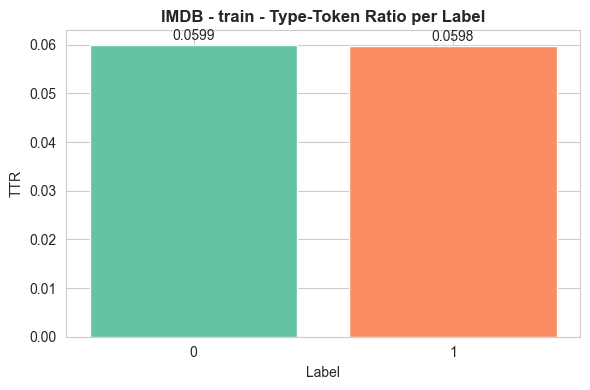


--- validation ---
  Overall TTR: 0.0786 (92,867 types / 1,181,920 tokens)
  Label 0 TTR: 0.0989 (57,390 types / 580,213 tokens)
  Label 1 TTR: 0.0998 (60,051 types / 601,707 tokens)


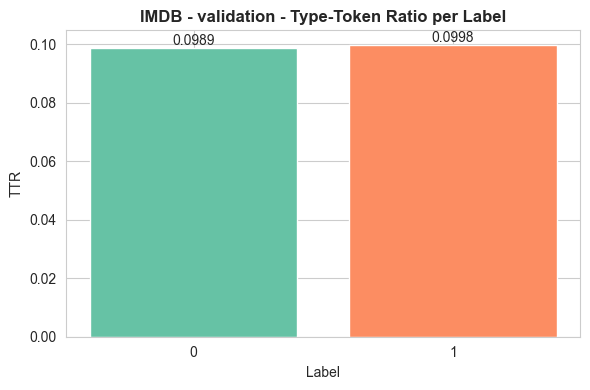


--- test ---
  Overall TTR: 0.0433 (247,630 types / 5,713,167 tokens)
  Label 0 TTR: 0.0547 (155,956 types / 2,850,766 tokens)
  Label 1 TTR: 0.0554 (158,691 types / 2,862,401 tokens)


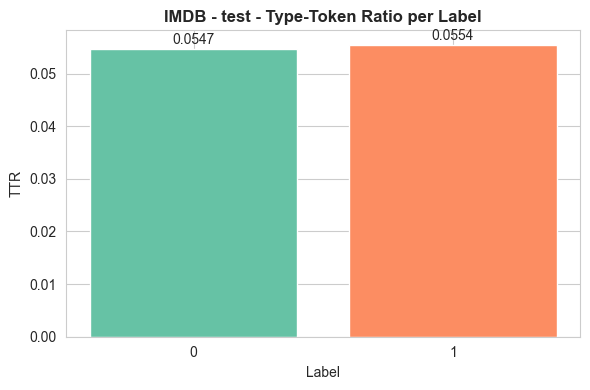

In [19]:
print(f"{'='*50}")
print(f"  Type-Token Ratio (TTR) - Lexical Diversity")
print(f"{'='*50}")

for split_name, df in splits.items():
    print(f"\n--- {split_name} ---")
    all_words = " ".join(df[TEXT_COLUMN].astype(str).tolist()).lower().split()
    ttr = len(set(all_words)) / len(all_words) if all_words else 0
    print(f"  Overall TTR: {ttr:.4f} ({len(set(all_words)):,} types / {len(all_words):,} tokens)")

    if LABEL_COLUMN in df.columns and df[LABEL_COLUMN].notna().any():
        labels_unique = sorted(df[LABEL_COLUMN].unique())
        ttr_per_label = {}
        for lbl in labels_unique:
            subset_words = " ".join(df[df[LABEL_COLUMN] == lbl][TEXT_COLUMN].astype(str).tolist()).lower().split()
            lbl_ttr = len(set(subset_words)) / len(subset_words) if subset_words else 0
            ttr_per_label[lbl] = lbl_ttr
            print(f"  Label {lbl} TTR: {lbl_ttr:.4f} ({len(set(subset_words)):,} types / {len(subset_words):,} tokens)")

        colors = sns.color_palette("Set2", len(labels_unique))
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar([str(l) for l in labels_unique], [ttr_per_label[l] for l in labels_unique], color=colors)
        for i, lbl in enumerate(labels_unique):
            ax.text(i, ttr_per_label[lbl] + 0.001, f"{ttr_per_label[lbl]:.4f}", ha="center", fontsize=10)
        ax.set_xlabel("Label")
        ax.set_ylabel("TTR")
        ax.set_title(f"{DATASET} - {split_name} - Type-Token Ratio per Label", fontweight="bold")
        fig.tight_layout()
        fig.savefig(os.path.join(EDA_DIR, f"ttr_per_label_{split_name}.png"), dpi=150, bbox_inches="tight")
        plt.show()

  Stopwords Ratio Analysis
  Using 198 NLTK English stopwords

--- train ---
  Mean stopword ratio: 0.4534
  Median stopword ratio: 0.4550
  Label 0: mean=0.4547, median=0.4564
  Label 1: mean=0.4520, median=0.4531


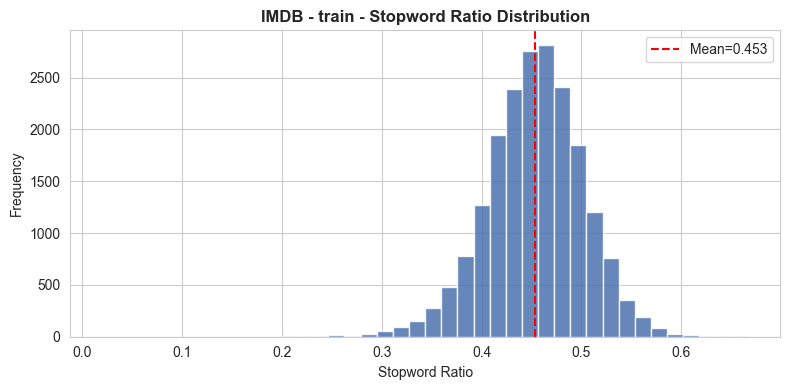

--- validation ---
  Mean stopword ratio: 0.4526
  Median stopword ratio: 0.4545
  Label 0: mean=0.4538, median=0.4561
  Label 1: mean=0.4515, median=0.4525


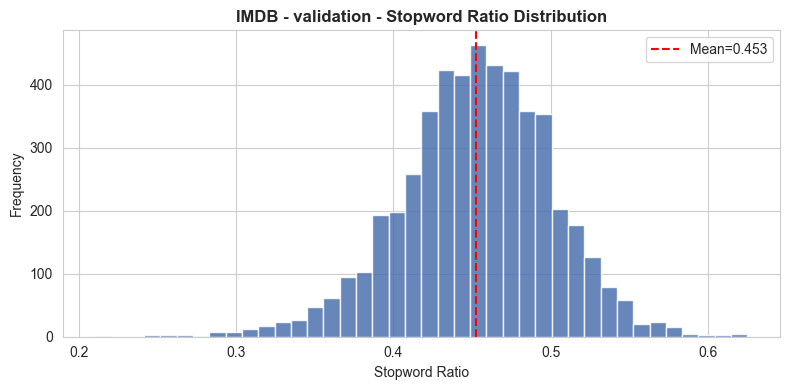

--- test ---
  Mean stopword ratio: 0.4535
  Median stopword ratio: 0.4553
  Label 0: mean=0.4543, median=0.4560
  Label 1: mean=0.4528, median=0.4545


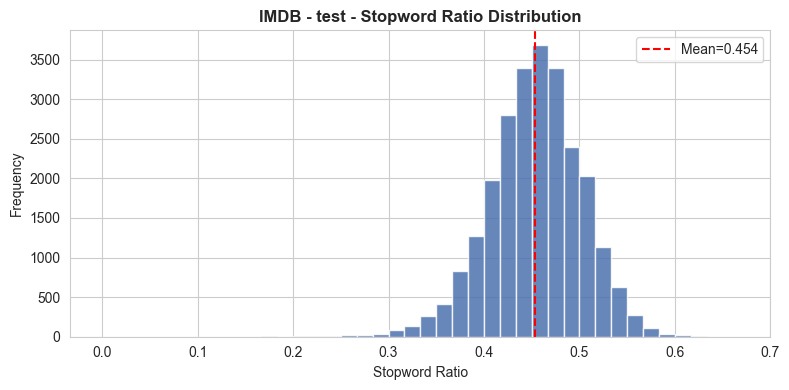

In [20]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))

print(f"{'='*50}")
print(f"  Stopwords Ratio Analysis")
print(f"{'='*50}")
print(f"  Using {len(STOP_WORDS)} NLTK English stopwords\n")

for split_name, df in splits.items():
    df["stopword_count"] = df[TEXT_COLUMN].apply(
        lambda t: sum(1 for w in str(t).lower().split() if w in STOP_WORDS)
    )
    df["stopword_ratio"] = df["stopword_count"] / df["word_count"].replace(0, 1)
    splits[split_name] = df

    print(f"--- {split_name} ---")
    print(f"  Mean stopword ratio: {df['stopword_ratio'].mean():.4f}")
    print(f"  Median stopword ratio: {df['stopword_ratio'].median():.4f}")

    if LABEL_COLUMN in df.columns and df[LABEL_COLUMN].notna().any():
        labels_unique = sorted(df[LABEL_COLUMN].unique())
        for lbl in labels_unique:
            subset = df[df[LABEL_COLUMN] == lbl]
            print(f"  Label {lbl}: mean={subset['stopword_ratio'].mean():.4f}, "
                  f"median={subset['stopword_ratio'].median():.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df["stopword_ratio"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(df["stopword_ratio"].mean(), color="red", linestyle="--",
               label=f"Mean={df['stopword_ratio'].mean():.3f}")
    ax.set_xlabel("Stopword Ratio")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{DATASET} - {split_name} - Stopword Ratio Distribution", fontweight="bold")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(EDA_DIR, f"stopword_ratio_{split_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

  Punctuation & Special Characters Analysis

--- train ---
  Punctuation ratio  -- mean: 0.0402, median: 0.0381
  Samples with digits: 11285 (56.4%)
  Uppercase ratio    -- mean: 0.0277
  Special chars/text -- mean: 53.11


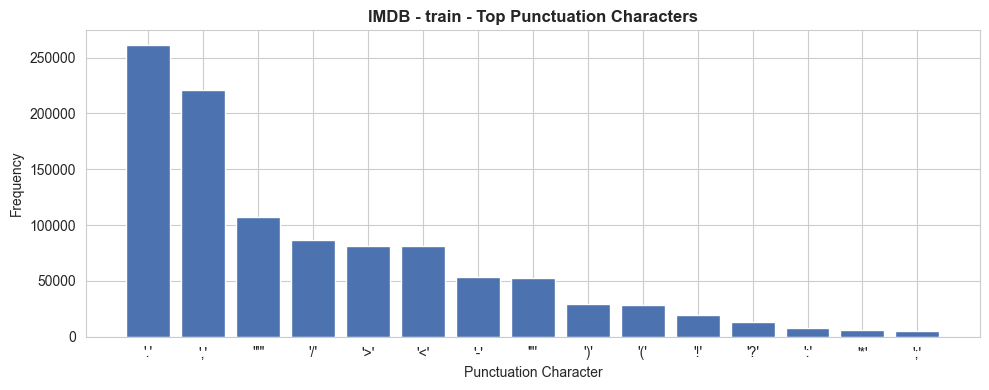


--- validation ---
  Punctuation ratio  -- mean: 0.0402, median: 0.0382
  Samples with digits: 2879 (57.6%)
  Uppercase ratio    -- mean: 0.0277
  Special chars/text -- mean: 53.72


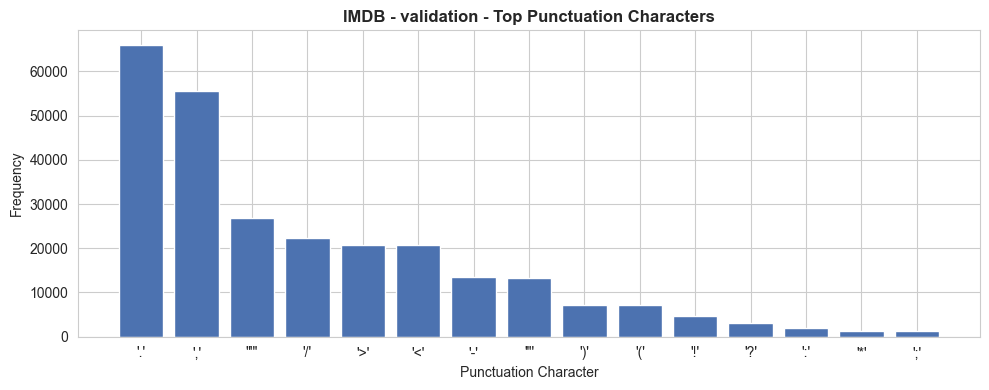


--- test ---
  Punctuation ratio  -- mean: 0.0402, median: 0.0381
  Samples with digits: 13841 (55.4%)
  Uppercase ratio    -- mean: 0.0278
  Special chars/text -- mean: 52.18


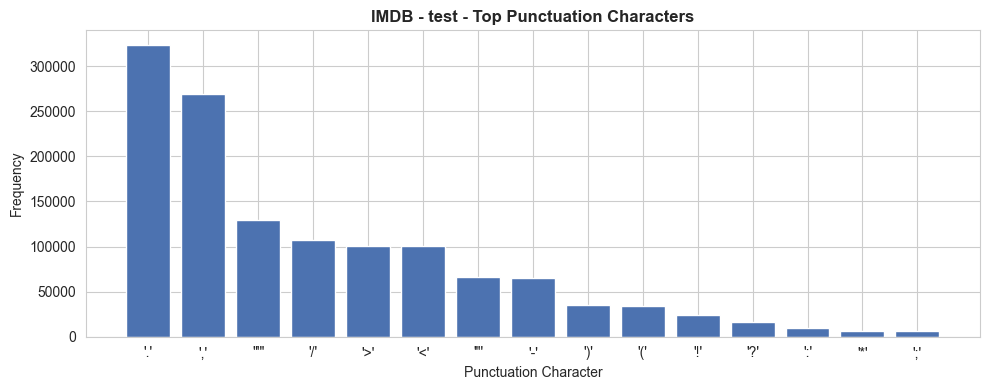

In [21]:
import string

print(f"{'='*50}")
print(f"  Punctuation & Special Characters Analysis")
print(f"{'='*50}")

PUNCT_SET = set(string.punctuation)

for split_name, df in splits.items():
    df["punct_count"] = df[TEXT_COLUMN].apply(
        lambda t: sum(1 for c in str(t) if c in PUNCT_SET)
    )
    df["punct_ratio"] = df["punct_count"] / df["char_count"].replace(0, 1)
    df["has_digits"] = df[TEXT_COLUMN].apply(lambda t: bool(re.search(r"\d", str(t))))
    df["has_uppercase"] = df[TEXT_COLUMN].apply(
        lambda t: sum(1 for c in str(t) if c.isupper()) / max(len(str(t)), 1)
    )
    df["special_chars"] = df[TEXT_COLUMN].apply(
        lambda t: sum(1 for c in str(t) if not c.isalnum() and c not in (" ", "\t", "\n"))
    )
    splits[split_name] = df

    print(f"\n--- {split_name} ---")
    print(f"  Punctuation ratio  -- mean: {df['punct_ratio'].mean():.4f}, "
          f"median: {df['punct_ratio'].median():.4f}")
    print(f"  Samples with digits: {df['has_digits'].sum()} ({df['has_digits'].mean()*100:.1f}%)")
    print(f"  Uppercase ratio    -- mean: {df['has_uppercase'].mean():.4f}")
    print(f"  Special chars/text -- mean: {df['special_chars'].mean():.2f}")

    all_chars = "".join(df[TEXT_COLUMN].astype(str).tolist())
    punct_counter = Counter(c for c in all_chars if c in PUNCT_SET)
    top_punct = punct_counter.most_common(15)
    if top_punct:
        chars, counts = zip(*top_punct)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar([repr(c) for c in chars], counts, color="#4C72B0")
        ax.set_xlabel("Punctuation Character")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{DATASET} - {split_name} - Top Punctuation Characters", fontweight="bold")
        fig.tight_layout()
        fig.savefig(os.path.join(EDA_DIR, f"punctuation_chars_{split_name}.png"), dpi=150, bbox_inches="tight")
        plt.show()

In [22]:
print("EDA complete!")

EDA complete!
